In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import scipy.stats as stats
import nibabel as nib
from nilearn import plotting
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight
from statsmodels.stats.multitest import fdrcorrection
from nilearn.image import new_img_like
import nilearn.image as nlimg
import seaborn as sns
from sklearn.metrics import pairwise_distances

In [2]:
def upper_tri(RDM):
    """upper_
     returns the upper triangular index of an RDM

    Args:
        RDM 2Darray: squareform RDM

    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

In [33]:
# Smoothing function: Moving average
def smooth(data, window_size=50):
    return np.convolve(data, np.ones(window_size) / window_size, mode='same')


def find_significant_clusters(data, baseline_mean, baseline_std, min_consecutive=5):
    # Calculate threshold as 5 standard deviations above baseline mean
    threshold = baseline_mean + 3 * baseline_std
    
    # Find points exceeding threshold AND positive correlation

    significant_points = (data > threshold) & (data > 0)
    
    # Find clusters of consecutive significant points
    significant_clusters = []
    count = 0
    start_idx = None
    
    for i in range(len(significant_points)):
        if significant_points[i]:
            if start_idx is None:
                start_idx = i
            count += 1
        else:
            if count >= min_consecutive:
                significant_clusters.extend(range(start_idx, start_idx + count))
            count = 0
            start_idx = None
            
    # Check for significant cluster at the end
    if count >= min_consecutive:
        significant_clusters.extend(range(start_idx, start_idx + count))
        
    return np.array(significant_clusters, dtype=int)

In [3]:
tmp_image_path = '../IAPS_fMRI_RSA/fMRI_singletrial_betas/nifti/Nt1.img'
# load one image to get the dimensions and make the mask

tmp_img = nib.load(tmp_image_path)

# Compute Gist RDM

In [26]:
gist_dir = "../IAPS_Gist_RDM/gist/"

In [8]:
gist_filelist = glob.glob(os.path.join(gist_dir, "*.txt"))  

In [9]:
type(gist_filelist)

list

In [10]:
stim_order = pd.read_csv("./IAPS_60_pnu.csv")
stim_order = np.array(stim_order['iaps_id'])
stim_order[:10]

array([4680, 4641, 8250, 8186, 4626, 2057, 4624, 4311, 4597, 4694],
      dtype=int64)

In [11]:
stim_order_txt = ["../IAPS_Gist_RDM/gist/{}.jpg.txt".format(i) for i in stim_order]
stim_order_txt

['../IAPS_Gist_RDM/gist/4680.jpg.txt',
 '../IAPS_Gist_RDM/gist/4641.jpg.txt',
 '../IAPS_Gist_RDM/gist/8250.jpg.txt',
 '../IAPS_Gist_RDM/gist/8186.jpg.txt',
 '../IAPS_Gist_RDM/gist/4626.jpg.txt',
 '../IAPS_Gist_RDM/gist/2057.jpg.txt',
 '../IAPS_Gist_RDM/gist/4624.jpg.txt',
 '../IAPS_Gist_RDM/gist/4311.jpg.txt',
 '../IAPS_Gist_RDM/gist/4597.jpg.txt',
 '../IAPS_Gist_RDM/gist/4694.jpg.txt',
 '../IAPS_Gist_RDM/gist/4610.jpg.txt',
 '../IAPS_Gist_RDM/gist/2332.jpg.txt',
 '../IAPS_Gist_RDM/gist/8030.jpg.txt',
 '../IAPS_Gist_RDM/gist/2655.jpg.txt',
 '../IAPS_Gist_RDM/gist/4658.jpg.txt',
 '../IAPS_Gist_RDM/gist/2345.jpg.txt',
 '../IAPS_Gist_RDM/gist/4599.jpg.txt',
 '../IAPS_Gist_RDM/gist/4695.jpg.txt',
 '../IAPS_Gist_RDM/gist/4693.jpg.txt',
 '../IAPS_Gist_RDM/gist/4668.jpg.txt',
 '../IAPS_Gist_RDM/gist/2305.jpg.txt',
 '../IAPS_Gist_RDM/gist/2347.jpg.txt',
 '../IAPS_Gist_RDM/gist/2398.jpg.txt',
 '../IAPS_Gist_RDM/gist/5781.jpg.txt',
 '../IAPS_Gist_RDM/gist/5600.jpg.txt',
 '../IAPS_Gist_RDM/gist/2

In [12]:
gist_file = [np.loadtxt(fname) for fname in stim_order_txt]

In [13]:
gist_file[0].shape

(512,)

In [14]:
gist_all = np.array(gist_file)

In [15]:
gist_all.shape

(60, 512)

In [16]:
gist_all_df = pd.DataFrame(gist_all.T)
gist_all_df.shape

(512, 60)

In [17]:
gist_rdm = 1-0.5 * (gist_all_df.corr(method="pearson") + 1)

In [18]:
gist_rdm.shape

(60, 60)

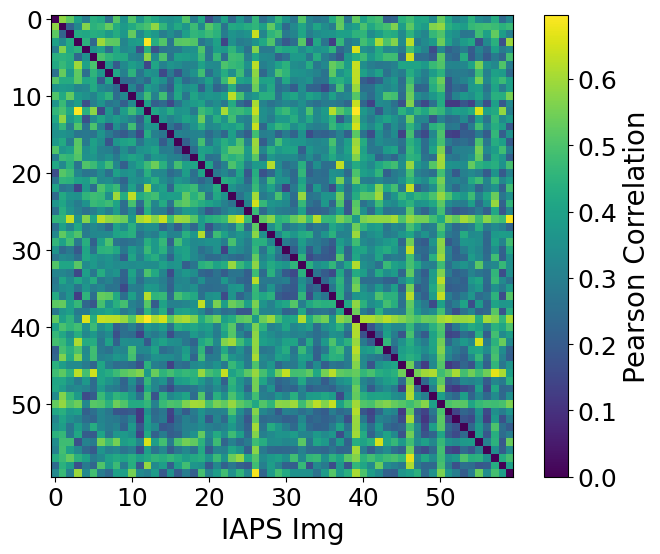

In [21]:
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size if needed

# Show image
shw = ax.imshow(gist_rdm)

# Add colorbar
bar = plt.colorbar(shw)

# Increase font size
plt.xlabel('IAPS Img', fontsize=20)  # Larger x-axis label
# plt.ylabel('IAPS Img', fontsize=20)  # Larger y-axis label
bar.set_label('Pearson Correlation', fontsize=20)  # Larger colorbar label

# Increase tick label size
ax.tick_params(axis='both', labelsize=18)  # Both x and y ticks
bar.ax.tick_params(labelsize=18)  # Colorbar tick labels



# Show plot
plt.show()


### RDM with correlation, normed

In [13]:
from scipy.spatial.distance import pdist, squareform
# Calculate the Euclidean distance between each pair of the 60 columns to form the RDM (Representational Dissimilarity Matrix)
gist_rdm_corr_norm = squareform(pdist(gist_all_df.T, metric='correlation'))
gist_rdm_corr_norm = (gist_rdm_corr_norm - gist_rdm_corr_norm.min()) / (gist_rdm_corr_norm.max() - gist_rdm_corr_norm.min())
# rdm should now be a (60, 60) array representing the pairwise Euclidean distances between columns
gist_rdm_corr_norm.shape

(60, 60)

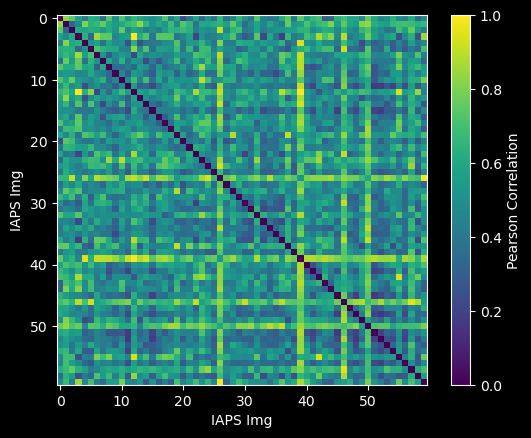

In [39]:
# import libraries
import matplotlib.pyplot as plt
plt.style.use('dark_background')
# make plot
fig, ax = plt.subplots()
  
# show image
shw = ax.imshow(gist_rdm_corr_norm)
  
# make bar
bar = plt.colorbar(shw)
  
# show plot with labels
plt.xlabel('IAPS Img')
plt.ylabel('IAPS Img')
bar.set_label('Pearson Correlation')
plt.show()

In [44]:
gist_model = ModelFixed('Gist RDM', upper_tri(gist_rdm_corr_norm))
gist_model.rdm.shape

(1770,)

### Export GIST correlation RDM

In [22]:
pd.DataFrame(gist_rdm_corr_norm).to_csv("../IAPS_Gist_RDM/gist_rdm_corr_norm.csv")


### RDM with Euclidean distance

In [15]:
from scipy.spatial.distance import pdist, squareform
# Calculate the Euclidean distance between each pair of the 60 columns to form the RDM (Representational Dissimilarity Matrix)
gist_rdm_euc = squareform(pdist(gist_all_df.T, metric='euclidean'))
gist_rdm_euc = (gist_rdm_euc - gist_rdm_euc.min()) / (gist_rdm_euc.max() - gist_rdm_euc.min())
# rdm should now be a (60, 60) array representing the pairwise Euclidean distances between columns
gist_rdm_euc.shape

(60, 60)

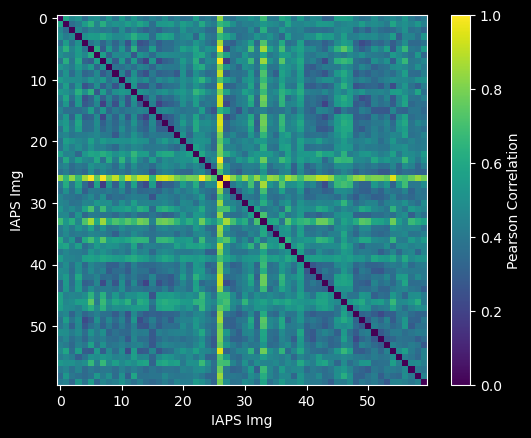

In [21]:
# import libraries
import matplotlib.pyplot as plt
plt.style.use('dark_background')
# make plot
fig, ax = plt.subplots()
  
# show image
shw = ax.imshow(gist_rdm_euc)
  
# make bar
bar = plt.colorbar(shw)
  
# show plot with labels
plt.xlabel('IAPS Img')
plt.ylabel('IAPS Img')
bar.set_label('Pearson Correlation')
plt.show()

In [16]:
gist_rdm = np.array(gist_rdm)
gist_rdm.shape

(60, 60)

In [22]:
gist_euc_model = ModelFixed('Gist RDM', upper_tri(gist_rdm_euc))
gist_euc_model.rdm.shape

(1770,)

### Export Gist RDM

In [20]:
pd.DataFrame(gist_rdm_euc).to_csv("../IAPS_Gist_RDM/gist_rdm_euc.csv")

### Import Gist RDM

In [41]:
gist_rdm = pd.read_csv("../IAPS_Gist_RDM/gist_rdm_euc.csv", index_col=0, header=0)
gist_rdm = np.array(gist_rdm)
gist_model = ModelFixed('Gist RDM', upper_tri(gist_rdm))
gist_model.rdm.shape

(1770,)

# Import neural RDM

In [47]:
dbfile = open('./outputs/20sub_fmri_rdm', 'rb')
sub_avg = pickle.load(dbfile)

In [48]:
len(sub_avg)

20

In [49]:
sub_avg[0].shape

(60, 153594)

# Import customized brain mask

    This mask keeps the voxels with non-zero values and removes any eyeball voxels. 

In [50]:
mask = np.load("../IAPS_Searchlight/mask.npy")

## Create searchlight centers and neighbours

In [52]:
centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)

Finding searchlights...:   0%|          | 0/59159 [00:00<?, ?it/s]

Finding searchlights...: 100%|██████████| 59159/59159 [00:24<00:00, 2411.18it/s]


Found 56949 searchlights


# Searchlight analysis 

In [54]:
eval_score_list = []
RDM_brain_list = []

for i in range(20):
    subj_data = sub_avg[i]
    subj_data_2d = np.nan_to_num(subj_data)

    image_value = np.arange(60)
    SL_RDM = get_searchlight_RDMs(subj_data_2d, centers, neighbors, image_value, method='correlation')

    eval_results = evaluate_models_searchlight(SL_RDM, gist_model, eval_fixed, method='spearman', n_jobs=3)
    # eval_results = evaluate_models_searchlight(SL_RDM, gist_euc_model, eval_fixed, method='spearman', n_jobs=3)
    # get the evaulation score for each voxel
    # We only have one model, but evaluations returns a list. By using float we just grab the value within that list
    eval_score = [float(e.evaluations) for e in eval_results]
    # Create an 3D array, with the size of mask, and
    x, y, z = mask.shape
    RDM_brain = np.zeros([x*y*z])
    RDM_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = eval_score
    RDM_brain = RDM_brain.reshape([x, y, z])

    eval_score_list.append(eval_score)
    RDM_brain_list.append(RDM_brain)


Evaluating models for each searchlight: 100%|██████████| 56949/56949 [01:57<00:00, 483.33it/s]
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_19132\766862423.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  eval_score = [float(e.evaluations) for e in eval_results]
Evaluating models for each searchlight: 100%|██████████| 56949/56949 [01:19<00:00, 715.45it/s]


In [55]:
# Export
# Save the evaluation scores and RDMs.
pd.DataFrame(eval_score_list).to_csv("./outputs/searchlight_results/20sub_SL_eval_score_norm_gist.csv")

dbfile= open('./outputs/searchlight_results/20sub_SL_eval_score_norm_gist', 'ab')
pickle.dump(RDM_brain_list, dbfile)                     
dbfile.close()



# Group analysis
When these results are used for group analysis across multiple subjects, it may be good to Fisher-transform the correlation values, so that they are more normally distributed.



In [20]:
# Import
eval_score_list = pd.read_csv("./outputs/searchlight_results/20sub_SL_eval_score_norm_gist.csv", header=0, index_col=0)
dbfile = open('./outputs/searchlight_results/20sub_SL_eval_score_norm_gist', 'rb')
RDM_brain_list = pickle.load(dbfile)


In [56]:
voxel_center_id = pd.read_csv("./outputs/voxel_center_id.csv", header=0, index_col=0)

In [57]:
print(np.array(eval_score_list).shape,'\n')
print(np.array(RDM_brain_list).shape,'\n')
print(len(voxel_center_id))

(20, 56949) 

(20, 53, 63, 46) 

56949


### Fisher z transformation

In [31]:
eval_score_array = np.array(eval_score_list)

# Fish's z-transformation
z_arr = np.arctanh(eval_score_array)

# standard z-transformation
mean_row = eval_score_array.mean(axis=1, keepdims=True)
std_row = eval_score_array.std(axis=1, keepdims=True)
z_arr = (eval_score_array - mean_row) / std_row


### T-test

In [32]:
t_stat_list = []
p_value_list = []

for i in range(z_arr.shape[-1]):
    t_statistic, p_value = stats.ttest_1samp(a=z_arr[:,i], popmean=0) 
    t_stat_list.append(t_statistic)
    p_value_list.append(p_value)

t_stat_array = np.array(t_stat_list)
p_value_array = np.array(p_value_list)

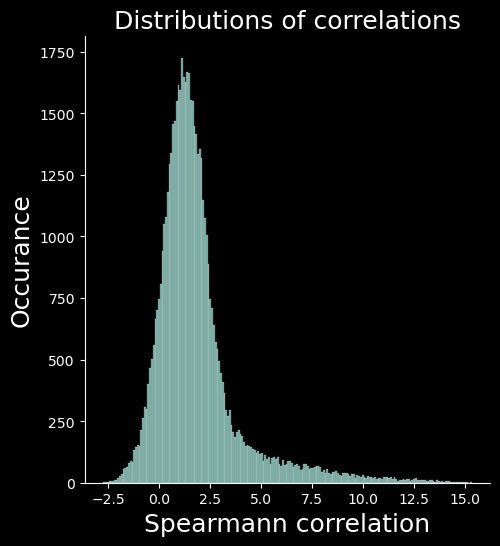

In [40]:
sns.displot(t_stat_array)
plt.title('Distributions of correlations', size=18)
plt.ylabel('Occurance', size=18)
plt.xlabel('Spearmann correlation', size=18)
sns.despine()
plt.show()

## Corrected p-values: FDR

In [34]:
reject_decision, corrected_pvalue = fdrcorrection(p_value_array, alpha=0.05, method='indep', is_sorted=False)

## Plot negative p-values

In [5]:
tmp_image_path = '../IAPS_fMRI_RSA/fMRI/nifti/Nt1.img'
# load one image to get the dimensions and make the mask

tmp_img = nib.load(tmp_image_path)

In [42]:
x, y, z = mask.shape
corrected_p_value_array = np.empty([x*y*z])
corrected_p_value_array[list(SL_RDM.rdm_descriptors['voxel_index'])] = corrected_pvalue
neg_log_corrected_p = np.log10(corrected_p_value_array) * (-1)
neg_log_corrected_p_brain = neg_log_corrected_p.reshape([x, y, z])

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_6076\2821812379.py:4: RuntimeWarning: divide by zero encountered in log10
  neg_log_corrected_p = np.log10(corrected_p_value_array) * (-1)


c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\_utils\niimg.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_stat_map.py:219: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  bg_img = load_mni152_template()
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



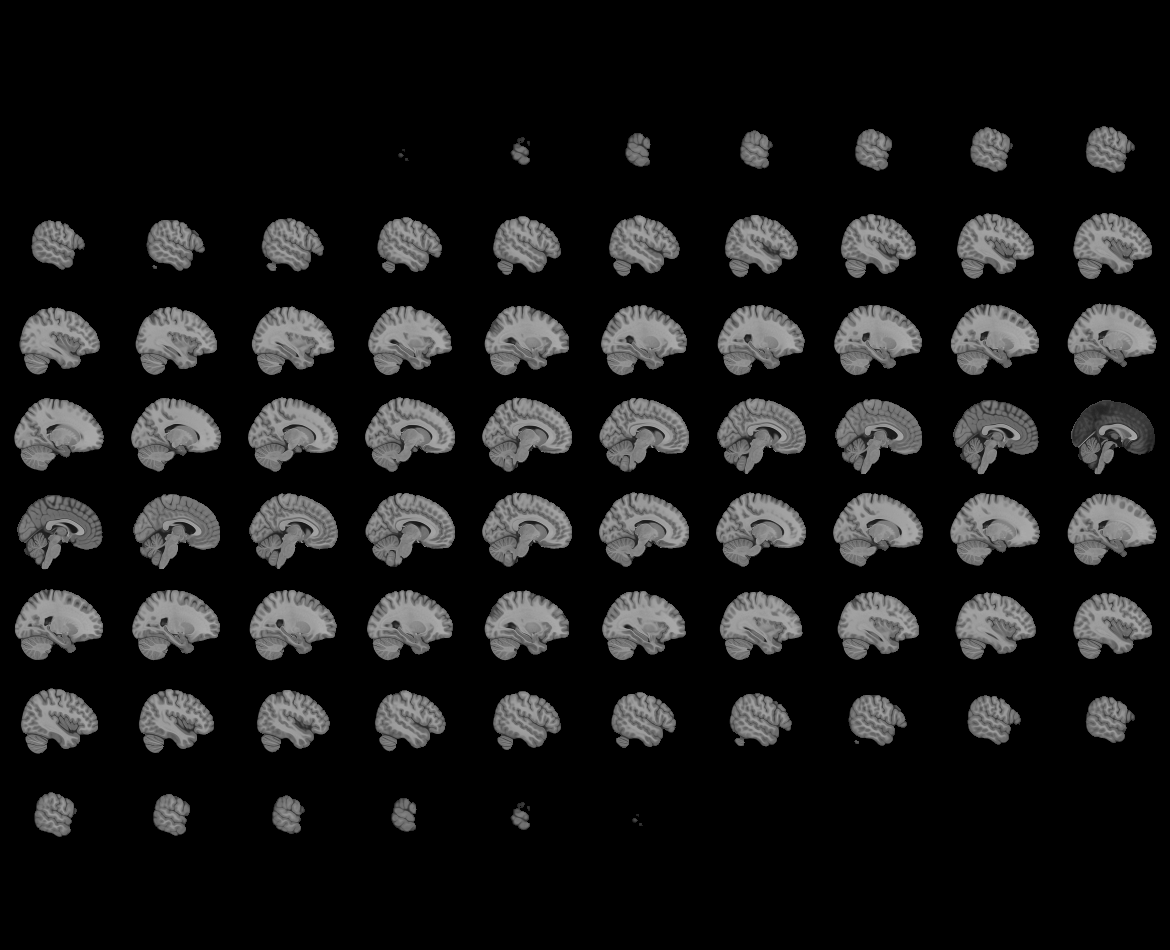
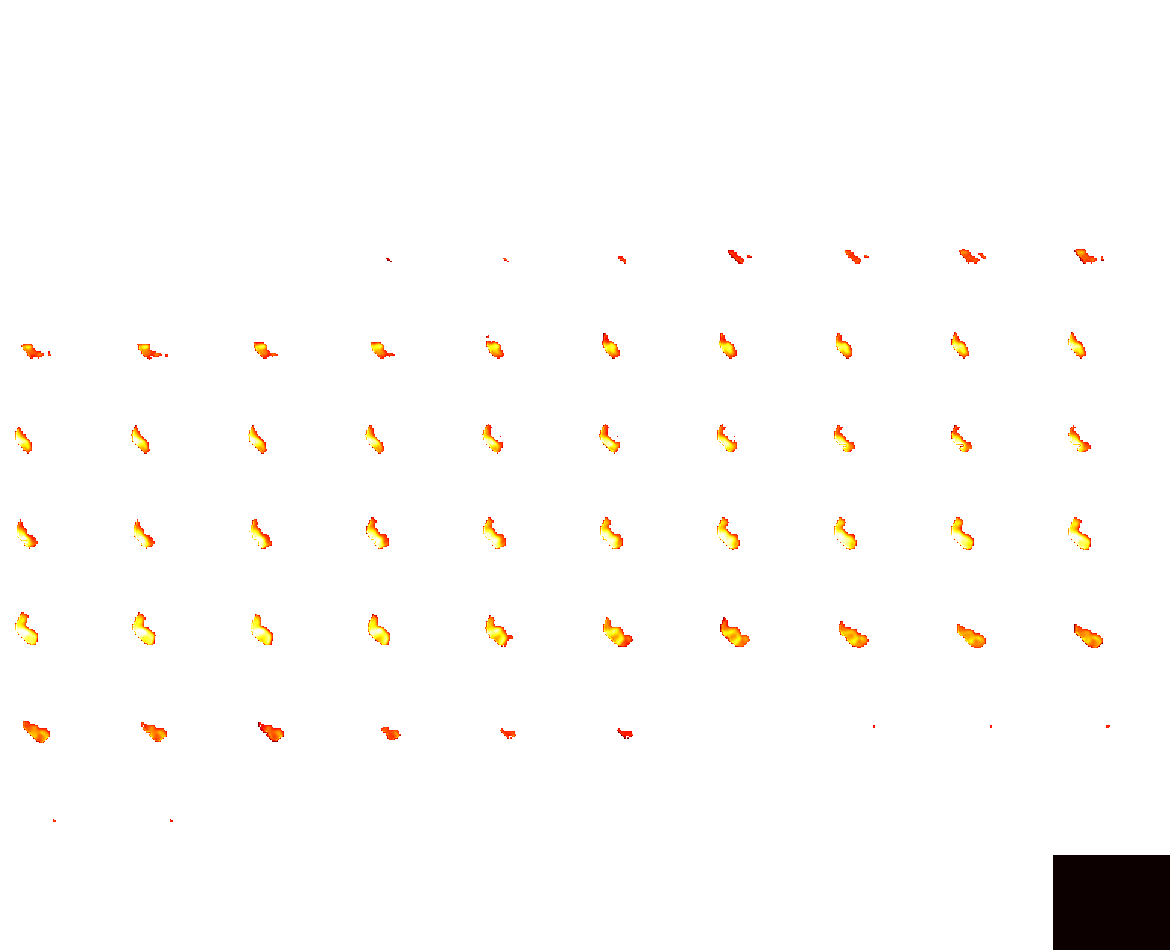

In [44]:
plot_corrected_neglog_pvalue_img = new_img_like(tmp_img, neg_log_corrected_p_brain)
view = plotting.view_img(plot_corrected_neglog_pvalue_img, threshold = 3)
view

## Mask the voxels with significant p-values and plot t statistics


In [35]:
sig_voxel = np.where(corrected_pvalue<0.01)

In [36]:
x, y, z = mask.shape
# t_stat_sig = np.full(([x*y*z]), np.nan)
t_stat_sig = np.empty([x*y*z])
t_stat_sig[np.array(SL_RDM.rdm_descriptors['voxel_index'])[sig_voxel]] = t_stat_array[sig_voxel]

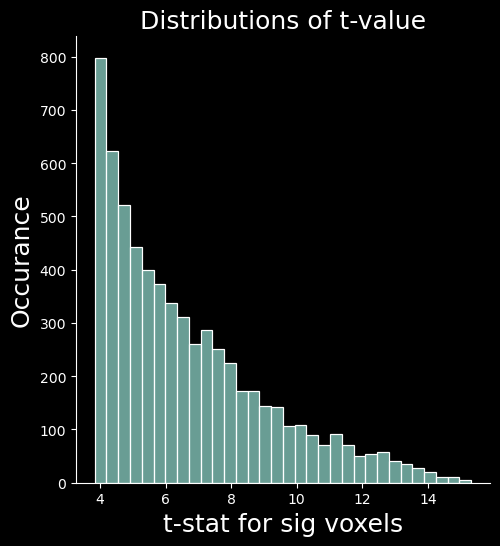

In [54]:
sns.displot(t_stat_array[sig_voxel])
plt.title('Distributions of t-value', size=18)
plt.ylabel('Occurance', size=18)
plt.xlabel('t-stat for sig voxels', size=18)
sns.despine()
plt.show()

In [55]:
np.count_nonzero(t_stat_sig)

6314

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



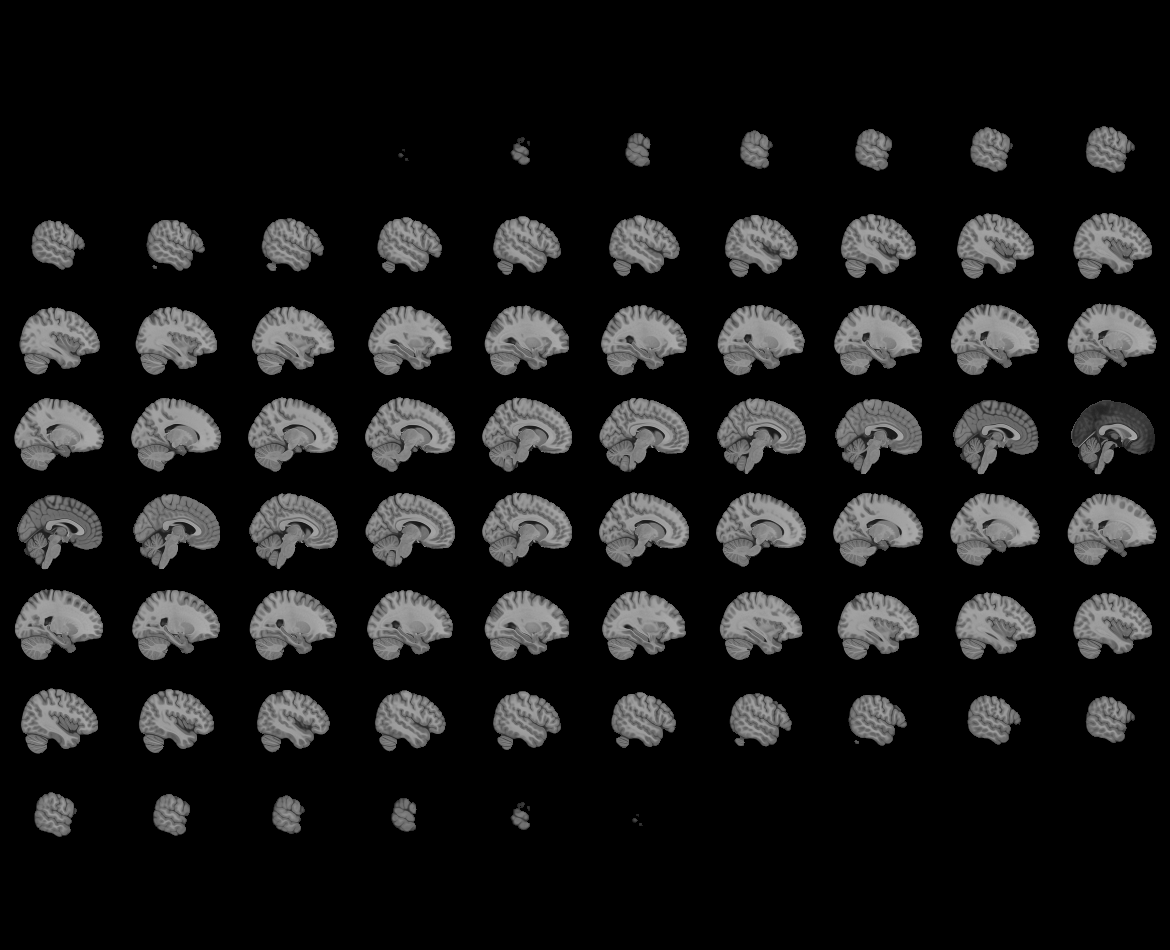
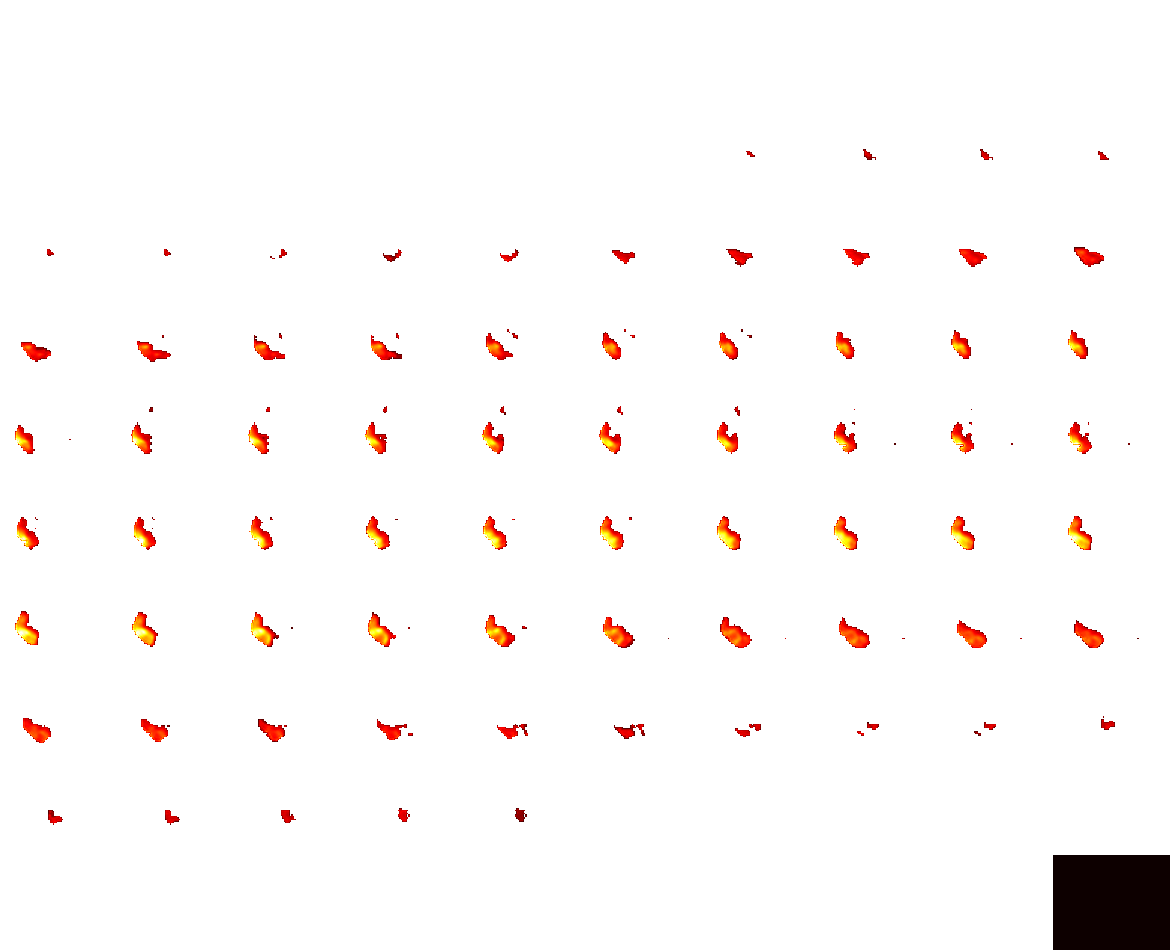

In [56]:
t_stat_sig_3d = t_stat_sig.reshape([x, y, z])
t_stat_sig_img = new_img_like(tmp_img, t_stat_sig_3d)
view = plotting.view_img(t_stat_sig_img)
view

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_stat_map.py:219: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  bg_img = load_mni152_template()
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



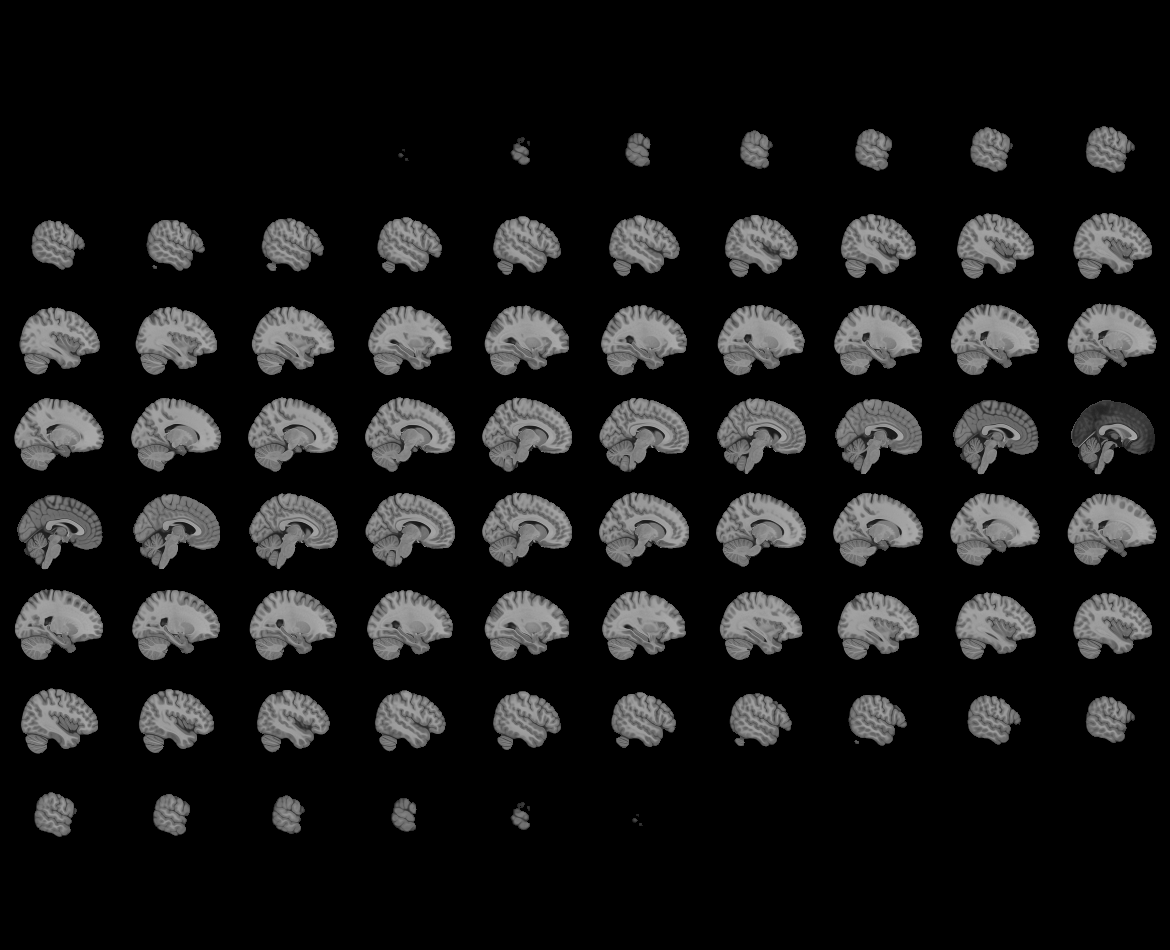
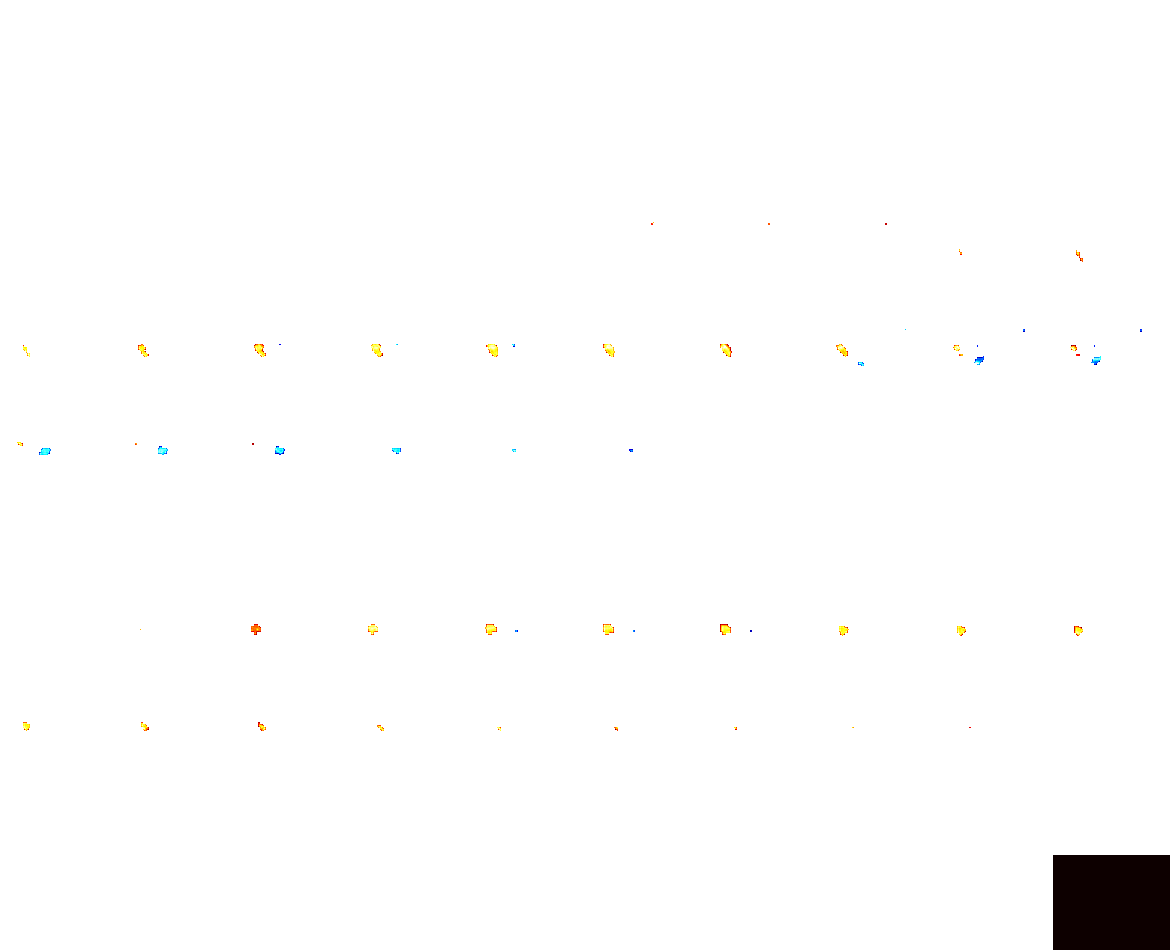

In [37]:
t_stat_sig_3d = t_stat_sig.reshape([x, y, z])
t_stat_sig_img = new_img_like(tmp_img, t_stat_sig_3d)
view = plotting.view_img(t_stat_sig_img)
view

In [40]:
t_stat_sig_img_clsuter = nlimg.threshold_img(t_stat_sig_img, 0, cluster_threshold=20)

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_document.py:59: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn('It seems you have created more than {} '



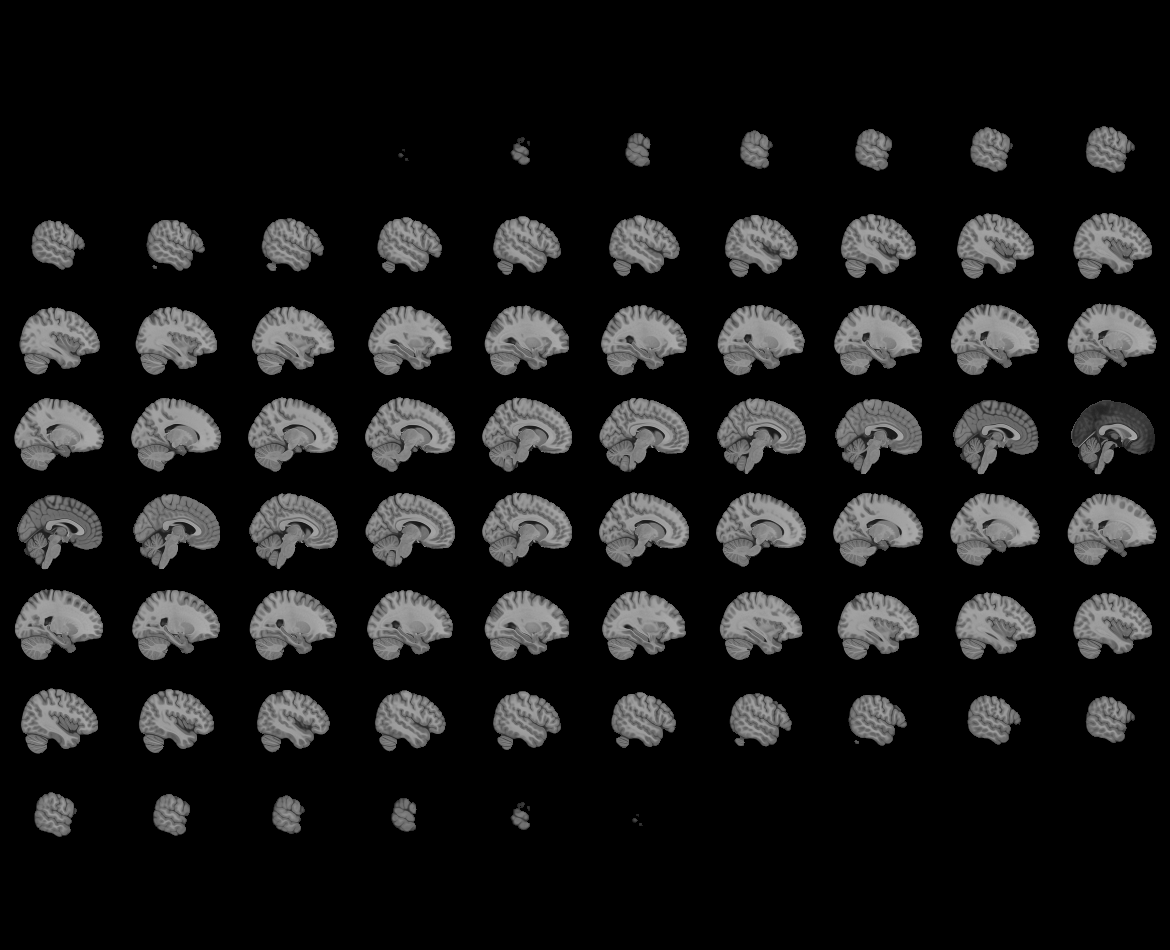
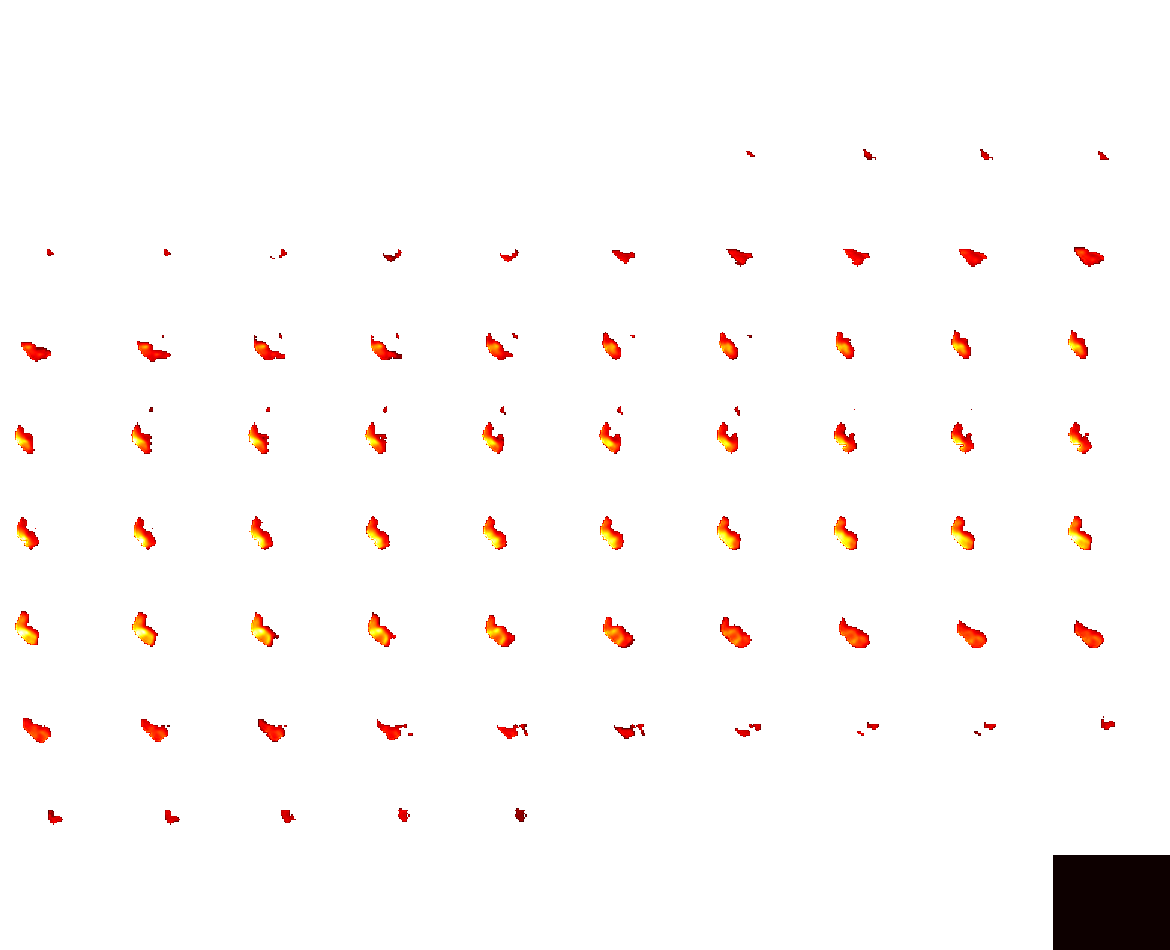

In [104]:
view = plotting.view_img(t_stat_sig_img_clsuter)
view

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



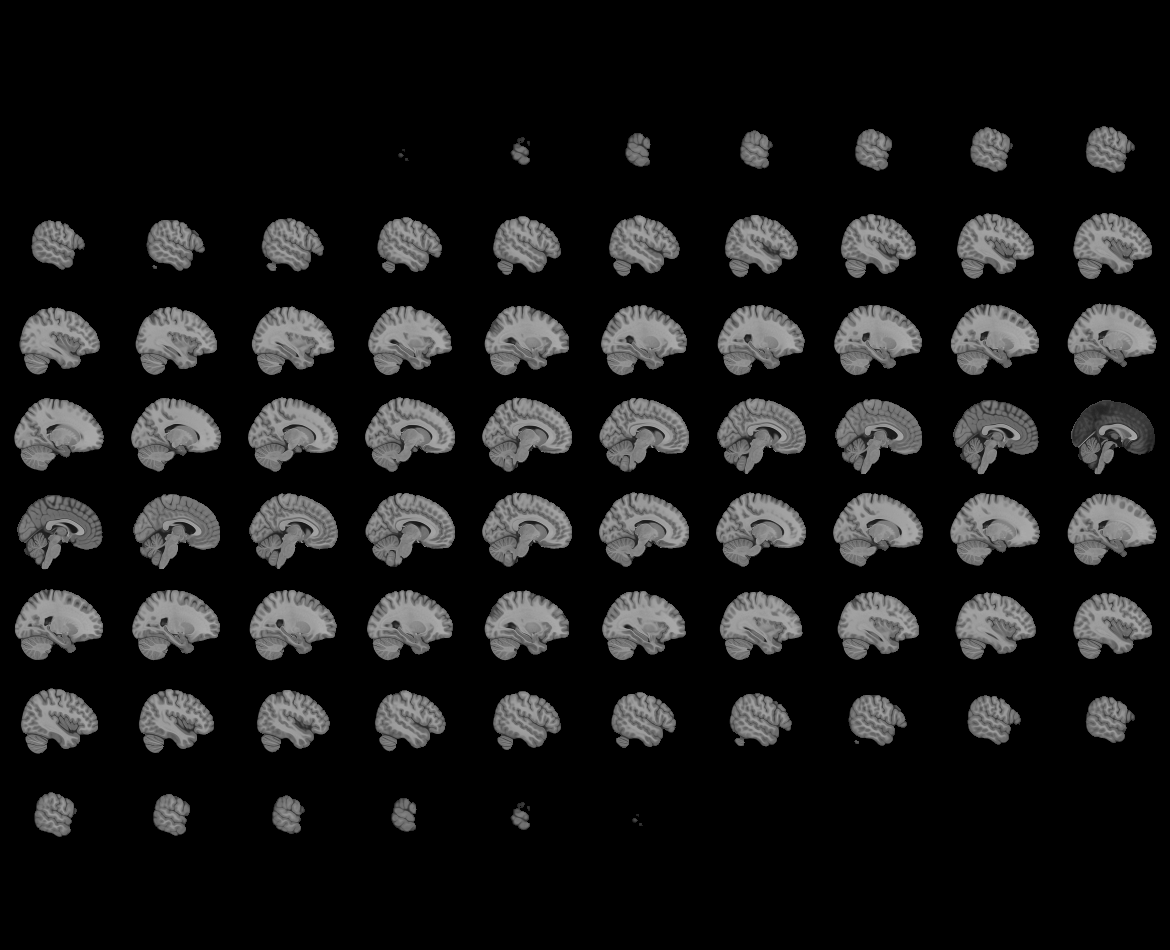
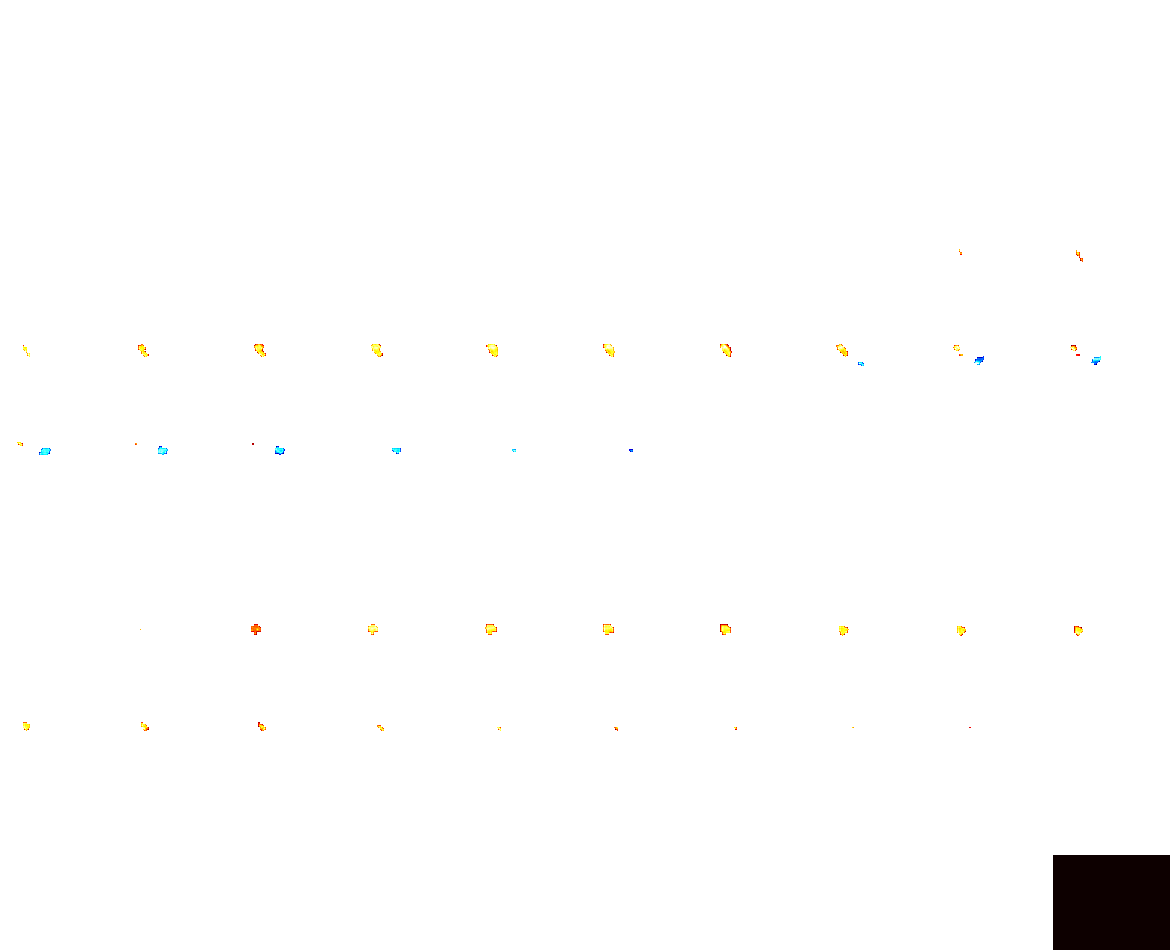

In [41]:
view = plotting.view_img(t_stat_sig_img_clsuter)
view

In [105]:
np.count_nonzero(t_stat_sig_img_clsuter.get_fdata())

6280

In [43]:
nib.save(t_stat_sig_img_clsuter, os.path.join("./outputs/tBrainmap", 'tmap_gist_p01_euc.nii.gz'))

In [42]:
nib.save(t_stat_sig_img_clsuter, os.path.join("C:/Users/yujunchen/Dropbox (UFL)/Searchlight results", 'tmap_gist_p01_euc.nii.gz'))

## All in one analysis

In [4]:
# Import
eval_score_list = pd.read_csv("./outputs/searchlight_results/SL_eval_score_norm_gist_norm.csv", header=0, index_col=0)
dbfile = open('./outputs/searchlight_results/SL_rdm_score_gist_norm', 'rb')
RDM_brain_list = pickle.load(dbfile)


In [2]:
# Import
eval_score_list = pd.read_csv("./outputs/searchlight_results/20sub_SL_eval_score_norm_gist.csv", header=0, index_col=0)
dbfile = open('./outputs/searchlight_results/20sub_SL_eval_score_norm_gist', 'rb')
RDM_brain_list = pickle.load(dbfile)


In [3]:
voxel_center_id = pd.read_csv("./outputs/voxel_center_id.csv", header=0, index_col=0)

In [12]:
from scipy.stats import ttest_1samp

# 1. Apply Fisher's transformation to the correlation coefficients
# fisher_z_scores = 0.5 * np.log((1 + eval_score_array) / (1 - eval_score_array))

eval_score_array = np.array(eval_score_list)
fisher_z_scores = np.arctanh(eval_score_array)

# 2. Perform t-tests voxel by voxel across subjects
t_stat_array, p_value_array = ttest_1samp(fisher_z_scores, 0, axis=0)

# 3. Apply FDR correction to p-values
reject_decision, corrected_pvalue = fdrcorrection(p_value_array, alpha=0.001, method='indep')

# 4. Select significant voxels based on the corrected p-values
sig_voxel = np.where(corrected_pvalue < 0.001)[0]

# Dimensions of the voxel space (x, y, z = 53, 63, 46)
x, y, z = 53, 63, 46

# Initialize an array for the t-statistics in 3D space
t_stat_sig = np.full((x * y * z), np.nan)

# Assign t-statistics to significant voxels
t_stat_sig[np.squeeze(np.array(voxel_center_id))[sig_voxel]] = t_stat_array[sig_voxel]

# Reshape the 1D t-statistics array into a 3D array matching the voxel space
t_stat_sig_3d = t_stat_sig.reshape([x, y, z])

# Set t-values less than 0 to NaN if you prefer not to show negative values
t_stat_sig_3d[t_stat_sig_3d < 0] = np.nan

# 5. Create a new image object from the 3D t-statistics
t_stat_sig_img = new_img_like(tmp_img, t_stat_sig_3d)

# 6. Apply cluster thresholding (optional)
t_stat_sig_img_cluster = nlimg.threshold_img(t_stat_sig_img, threshold=0, cluster_threshold=30)



C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18892\1341062464.py:37: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  t_stat_sig_img_cluster = nlimg.threshold_img(t_stat_sig_img, threshold=0, cluster_threshold=30)
c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro161\lib\site-packages\nilearn\image\image.py:997: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  img_data = safe_get_data(img, ensure_finite=True, copy_data=copy)


c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro161\lib\site-packages\numpy\_core\fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



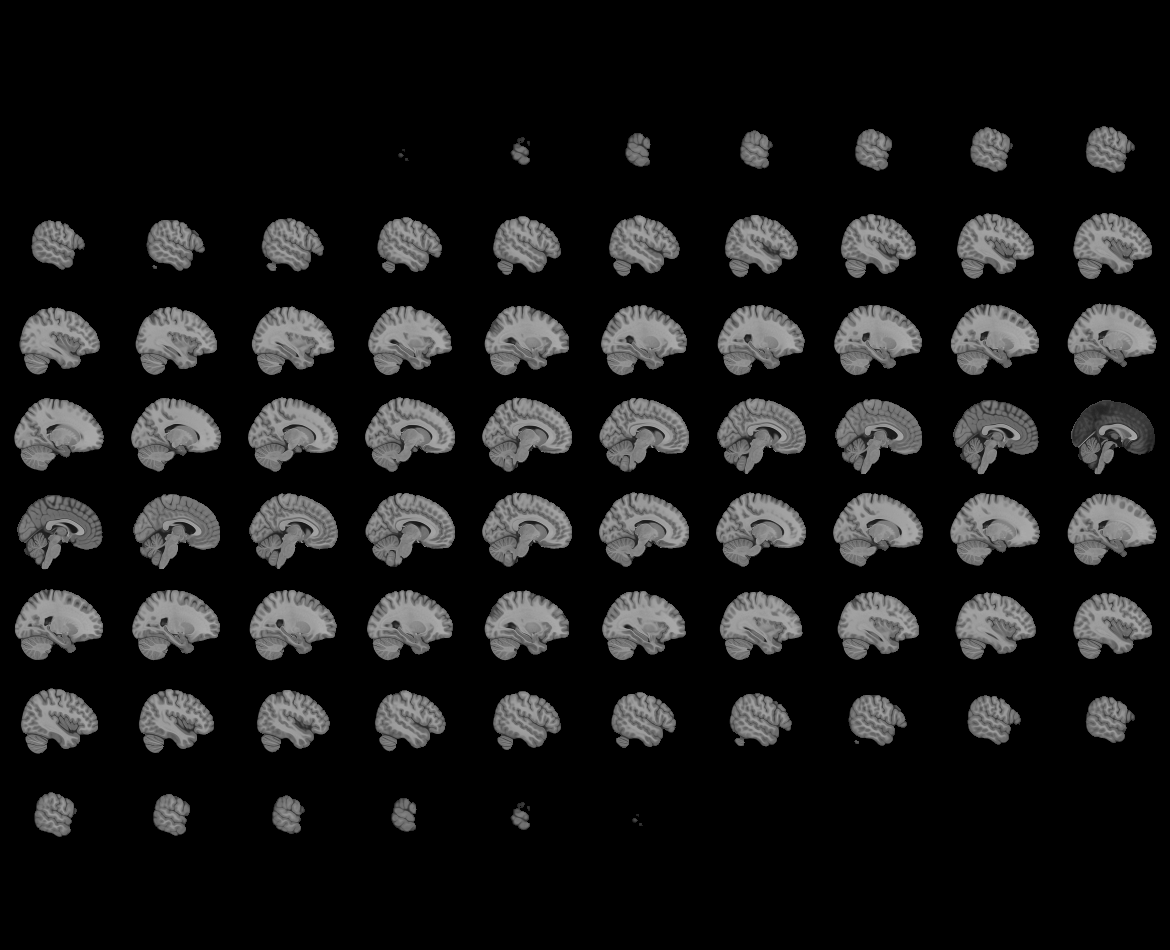
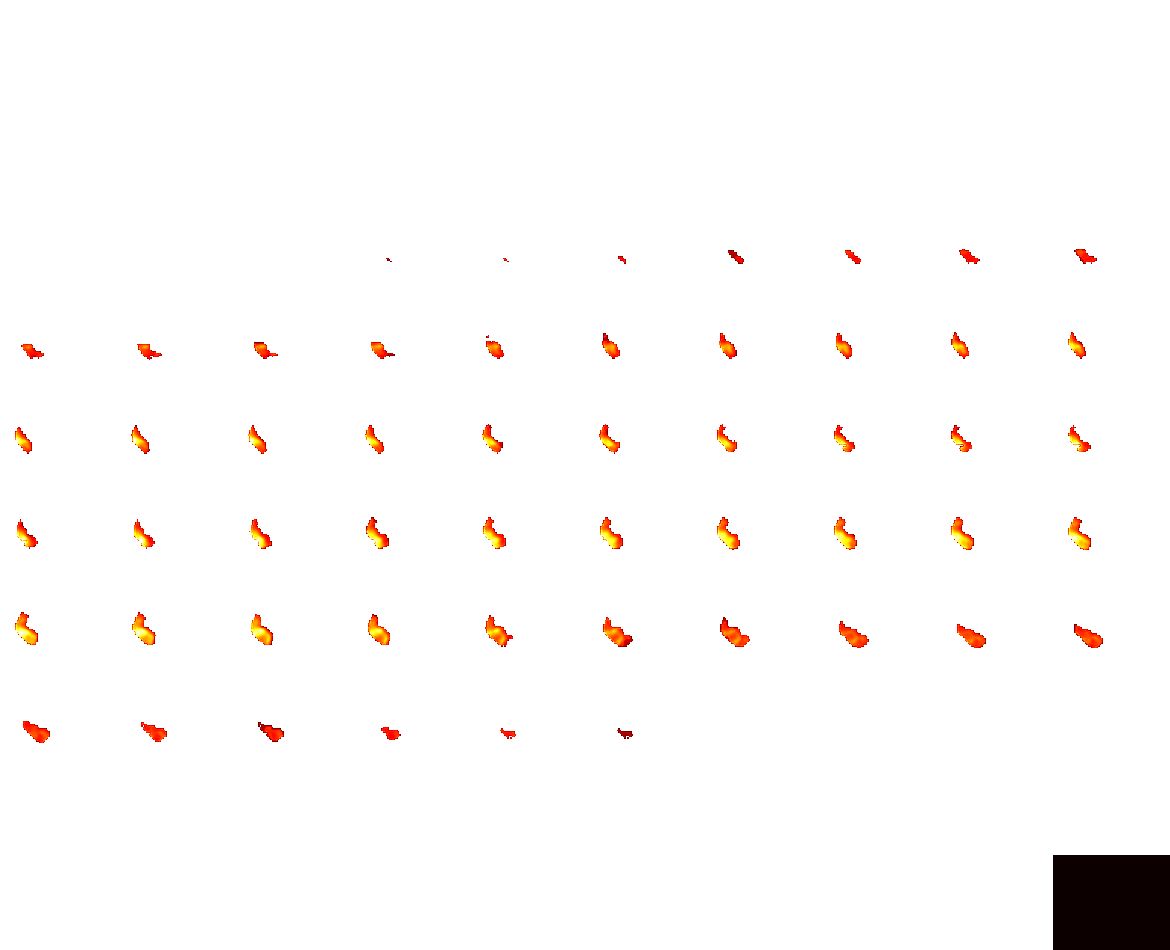

In [13]:
# 7. Visualize the significant voxel centers
view = plotting.view_img(t_stat_sig_img_cluster)
view

c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



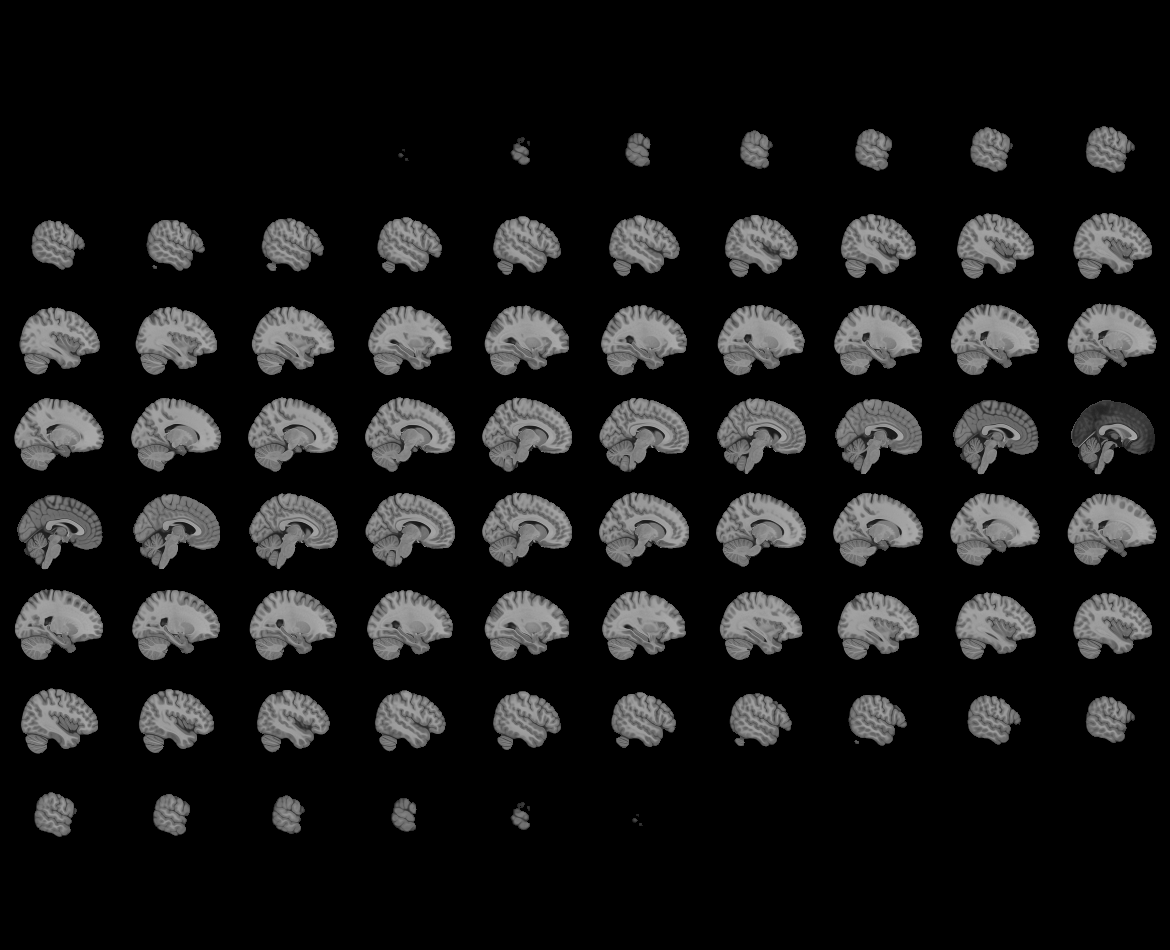
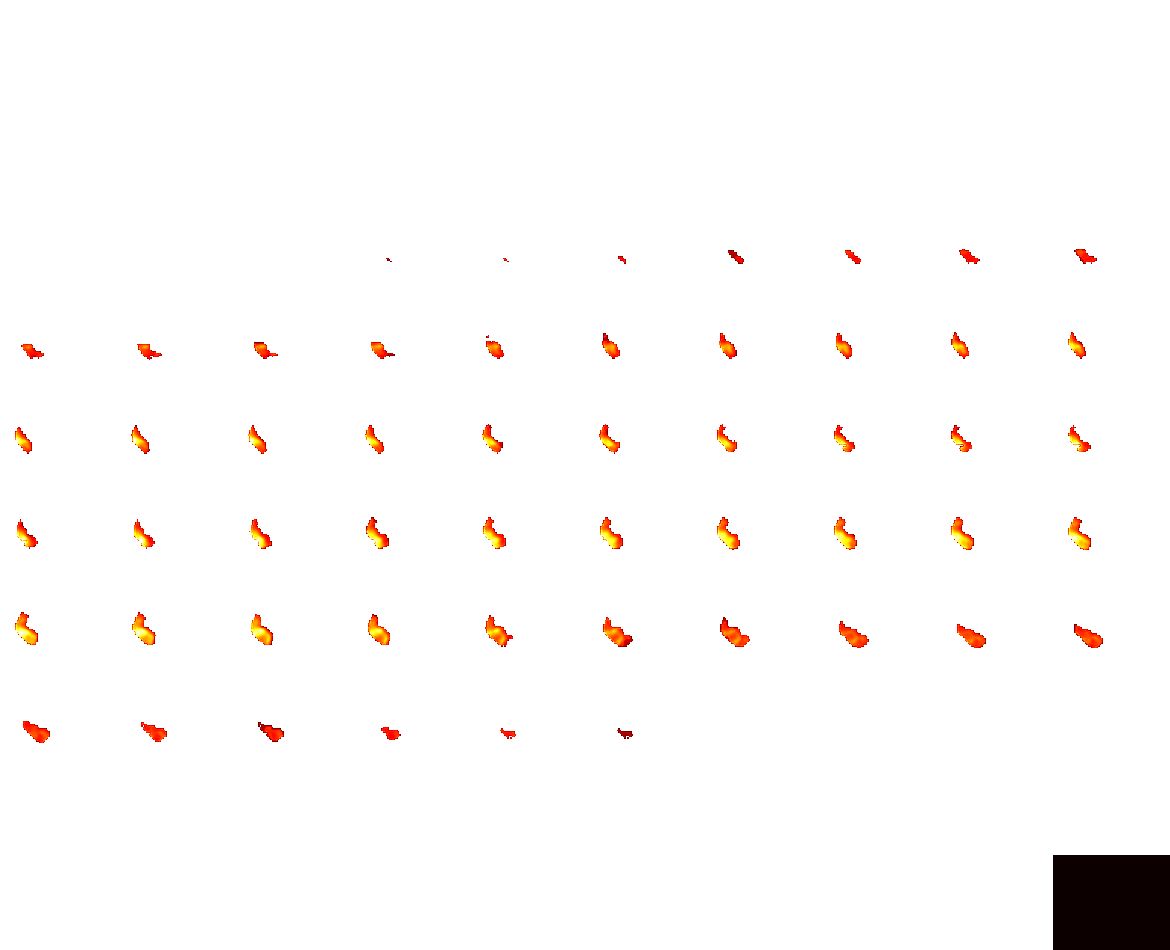

In [8]:
# 7. Visualize the significant voxel centers
view = plotting.view_img(t_stat_sig_img_cluster)
view

In [9]:
# Let's say you've already built t_stat_sig_3d.
# We'll threshold at t >= 6.7:
t_thresh = 6.7
t_stat_sig_3d[t_stat_sig_3d < t_thresh] = np.nan  # or 0 if you prefer

# Create a new 3D image object reflecting this threshold
t_stat_sig_img = new_img_like(tmp_img, t_stat_sig_3d)

# If you'd like to then apply cluster thresholding at this level:
t_stat_sig_img_cluster = nlimg.threshold_img(
    t_stat_sig_img,
    threshold=t_thresh,          # numeric threshold
    cluster_threshold=30,        # in voxels
    two_sided=False              # set True if you want abs(t) > threshold
)

c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\image\image.py:939: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  img_data = safe_get_data(img, ensure_finite=True, copy_data=copy)


c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



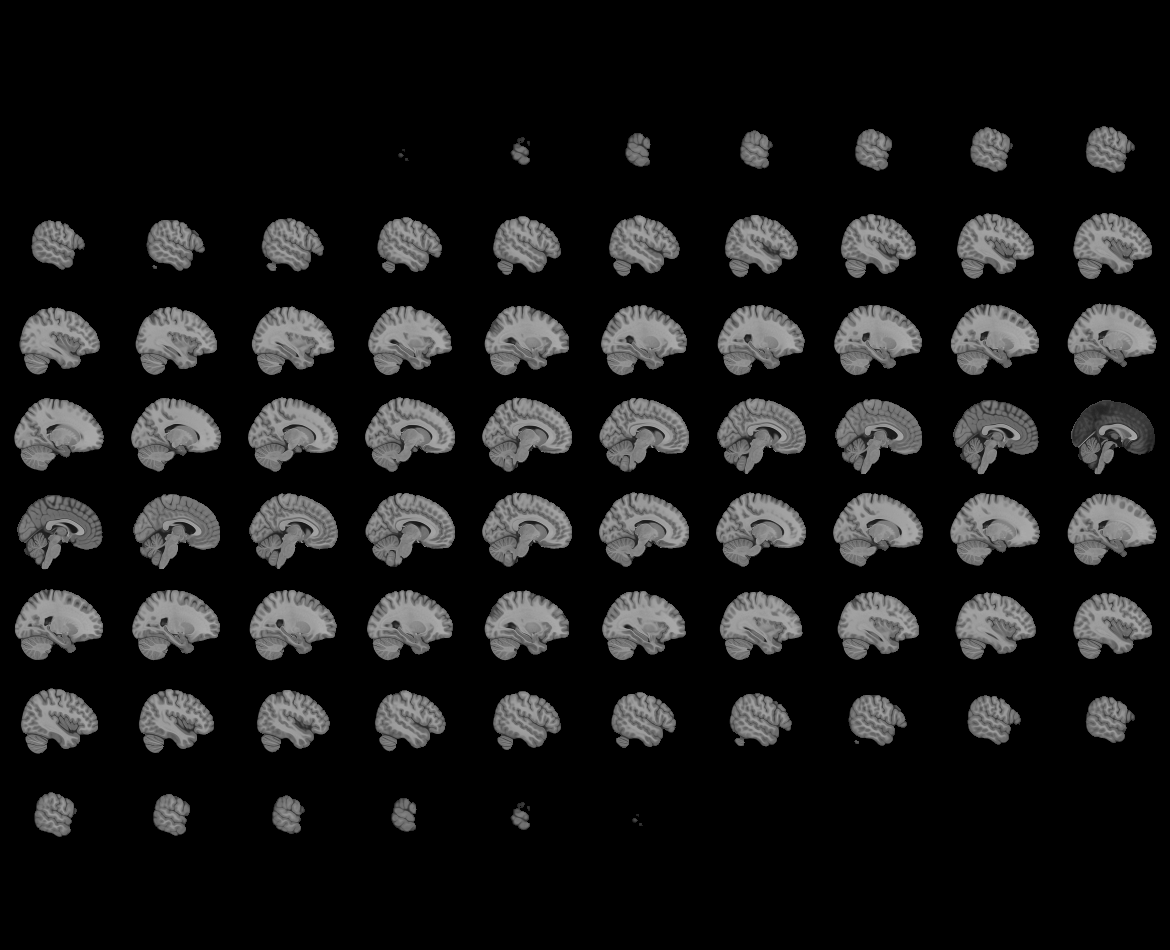
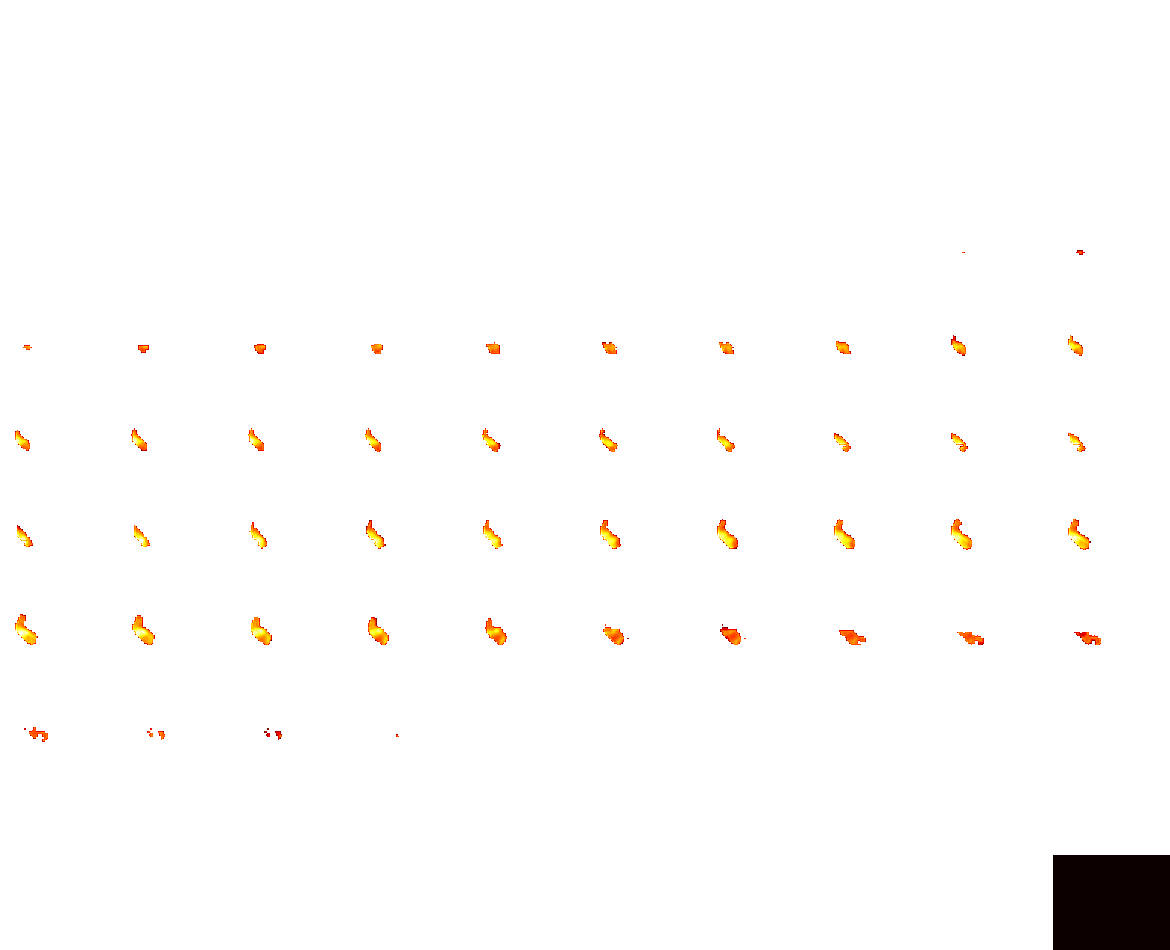

In [10]:
# 7. Visualize the significant voxel centers
view = plotting.view_img(t_stat_sig_img_cluster)
view

In [11]:
# Convert all nonzero values in loc_img to 1, and the rest to 0
evc_mask_data = (t_stat_sig_img_cluster.get_fdata() != 0).astype(int)

# Create a new NIfTI image for the binary visual mask
evc_mask_img = new_img_like(t_stat_sig_img_cluster, evc_mask_data)

# Define the output file path
output_file_path = r"F:\yujun\projects\IAPS_Searchlight\data\masks\evc_mask.nii.gz"

# Save the visual mask image as a .nii.gz file
evc_mask_img.to_filename(output_file_path)

random gist rdm

c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



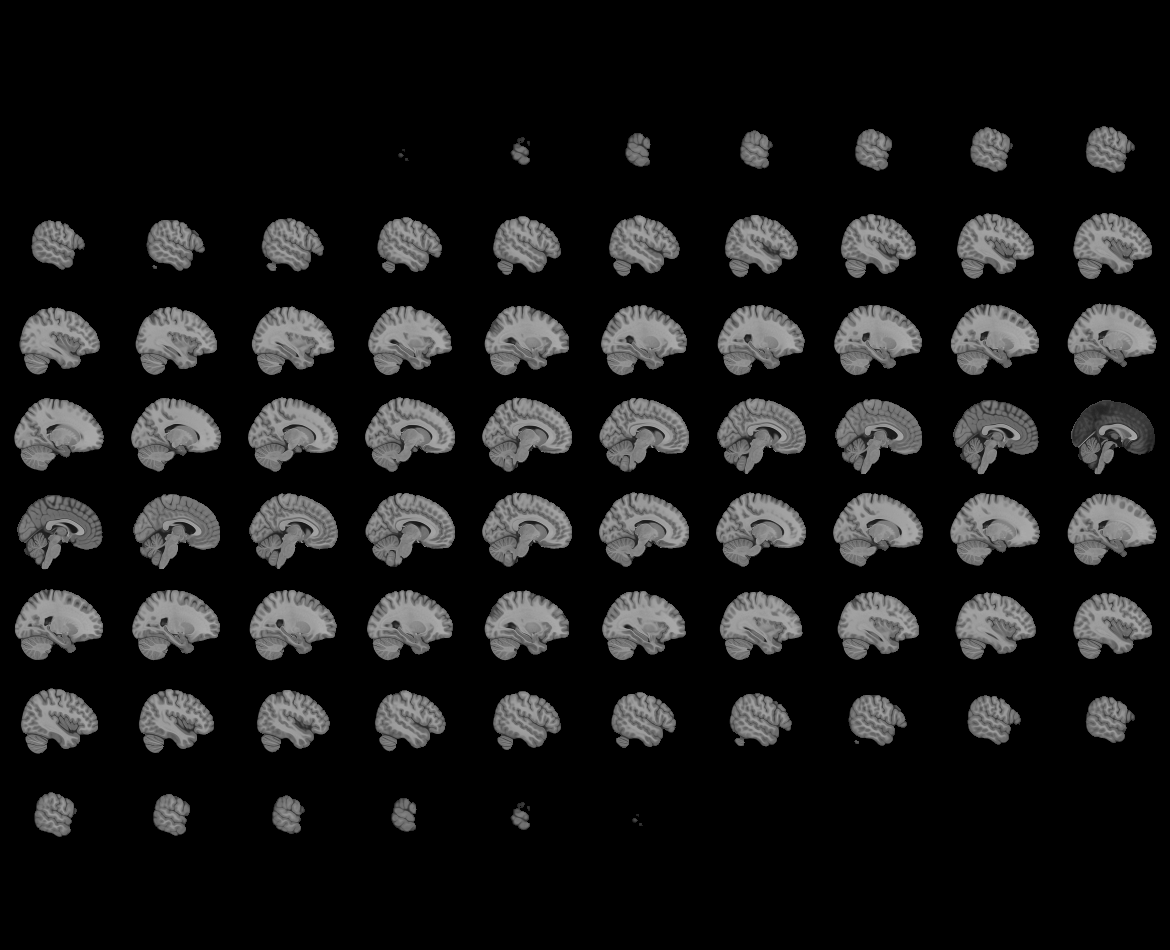
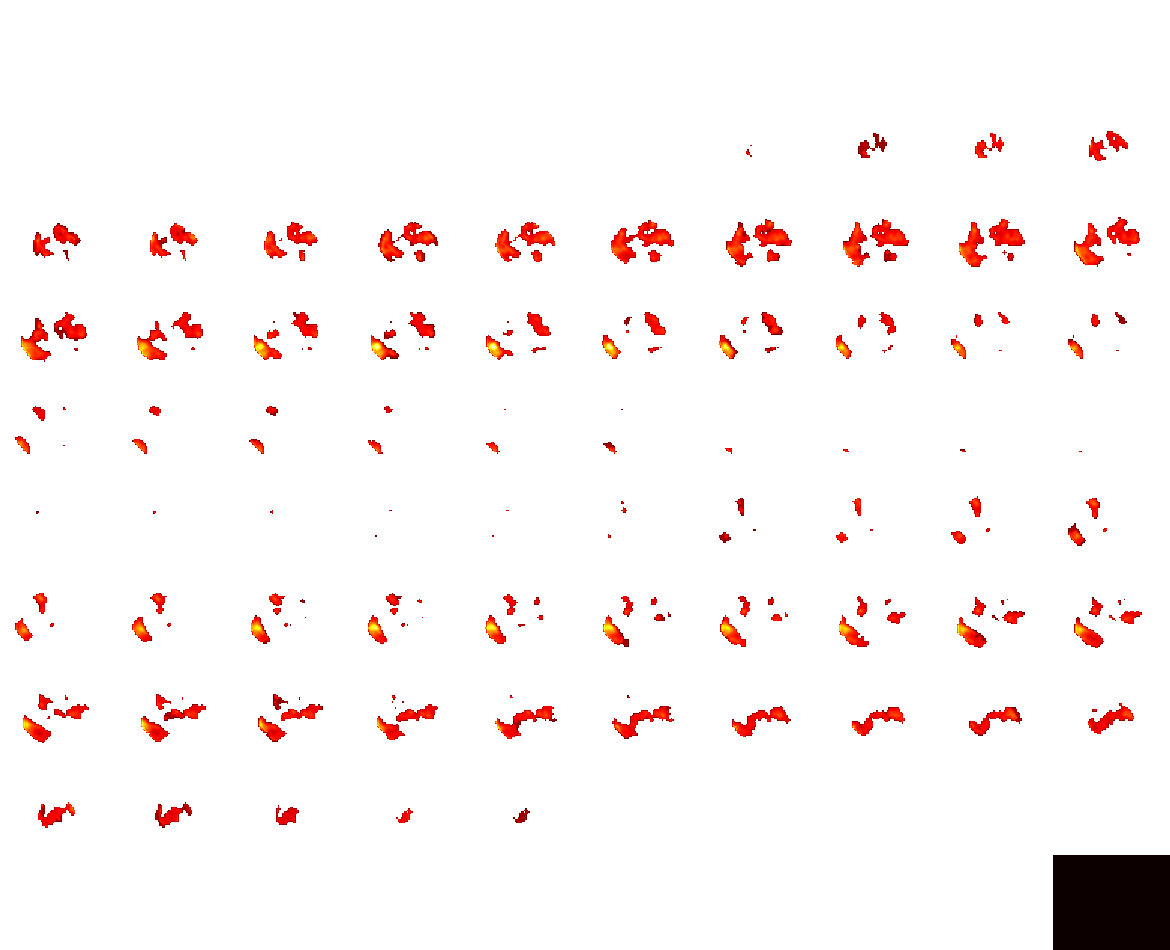

In [32]:
# 7. Visualize the significant voxel centers
view = plotting.view_img(t_stat_sig_img_cluster)
view

In [63]:
# nib.save(t_stat_sig_img_clsuter, os.path.join("./outputs/tBrainmap", 'tmap_beh60_p001_random.nii.gz'))
nib.save(t_stat_sig_img_cluster, os.path.join("./outputs/tBrainmap", 'tmap_gist_norm_p001.nii.gz'))

# Create EVC fMRI RDM

In [14]:
allsub_avg = np.load("allsub_avg.npy", allow_pickle=True)

In [17]:
evc_mask_data = evc_mask_img.get_fdata() > 0  # Motor mask binary
brain_data = allsub_avg.reshape(20, 60, *evc_mask_data.shape)
brain_data.shape

(20, 60, 53, 63, 46)

In [21]:
# Function to extract masked data and compute RDM
def compute_rdm(brain_data, mask, mask_name):
    """
    Compute the RDM for masked voxel data across stimuli.

    Parameters:
        brain_data (numpy array): Shape (20, 60, 53, 63, 46), brain data per subject.
        mask (numpy array): Binary mask of shape (53, 63, 46).
        mask_name (str): Name of the mask (for logging).

    Returns:
        rdms (numpy array): RDM of shape (20, 60, 60) for all subjects.
    """
    n_subjects, n_stimuli = brain_data.shape[:2]
    rdms = np.zeros((n_subjects, n_stimuli, n_stimuli))

    # Flatten the mask to 1D
    mask_flat = mask.ravel()  # Shape: (153594,)
    total_voxels_in_mask = np.sum(mask_flat)  # Total voxels selected by mask

    # Reshape brain data to (20, 60, num_voxels)
    brain_data_flat = brain_data.reshape(n_subjects, n_stimuli, -1)  # Shape: (20, 60, 153594)

    print(f"{mask_name}: Total voxel count in mask: {total_voxels_in_mask}")

    # Apply the mask to extract relevant voxels
    for subj in range(n_subjects):
        masked_data = brain_data_flat[subj][:, mask_flat > 0]  # Shape: (60, num_voxels_in_mask)

        # Check for NaN values in the masked data
        nan_count = np.isnan(masked_data).sum()
        if nan_count > 0:
            print(f"Subject {subj + 1}: Masked data contains {nan_count} NaN values. "
                  f"Total voxel count in the mask is {total_voxels_in_mask}.")

            # Optionally replace NaNs with 0 to proceed
            masked_data = np.nan_to_num(masked_data)

        # Ensure there are voxels to compute RDM
        if masked_data.shape[1] == 0:
            raise ValueError("Mask results in zero voxels being selected.")

        # Compute pairwise distances (RDM)
        rdm = pairwise_distances(masked_data, metric='correlation')  # Shape: (60, 60)
        rdms[subj] = rdm

    return rdms

# Apply the function
print("Calculating Motor RDMs...")
evc_rdms = compute_rdm(brain_data, evc_mask_data, "Motor Mask")  # Shape: (20, 60, 60)

# Print shapes for verification
print("\nMotor RDMs shape:", evc_rdms.shape)  # Should be (20, 60, 60)
    # Should be (20, 60, 60)

Calculating Motor RDMs...
Motor Mask: Total voxel count in mask: 2512
Subject 1: Masked data contains 900 NaN values. Total voxel count in the mask is 2512.
Subject 5: Masked data contains 120 NaN values. Total voxel count in the mask is 2512.
Subject 6: Masked data contains 780 NaN values. Total voxel count in the mask is 2512.
Subject 7: Masked data contains 120 NaN values. Total voxel count in the mask is 2512.
Subject 8: Masked data contains 600 NaN values. Total voxel count in the mask is 2512.
Subject 11: Masked data contains 480 NaN values. Total voxel count in the mask is 2512.
Subject 12: Masked data contains 1680 NaN values. Total voxel count in the mask is 2512.
Subject 13: Masked data contains 180 NaN values. Total voxel count in the mask is 2512.
Subject 17: Masked data contains 420 NaN values. Total voxel count in the mask is 2512.
Subject 18: Masked data contains 300 NaN values. Total voxel count in the mask is 2512.
Subject 19: Masked data contains 6120 NaN values. Tota

# RSA: EEG and EVC fMRI RDM

In [22]:
eeg_arr = np.load("../IAPS_EEG_RSA/eeg_raw.npy")
eeg_arr.shape

(20, 31, 60, 575)

In [30]:
# Function to compute EEG RDMs
def compute_eeg_rdms(eeg_arr, metric='correlation'):
    """
    Compute EEG RDMs based on the 31 EEG channels across stimuli and time points.

    Parameters:
        eeg_arr (numpy array): EEG data of shape (20, 31, 60, 575)
                              (subjects, channels, stimuli, time points).
        metric (str): Distance metric to use for RDM computation (e.g., 'correlation', 'euclidean').

    Returns:
        eeg_rdms (numpy array): RDMs of shape (20, 60, 60, 575)
                                (subjects, stimuli x stimuli, time points).
    """
    n_subjects, n_channels, n_stimuli, n_timepoints = eeg_arr.shape
    eeg_rdms = np.zeros((n_subjects, n_stimuli, n_stimuli, n_timepoints))

    # Iterate over subjects
    for subj in range(n_subjects):
        print(f"Processing Subject {subj + 1}/{n_subjects}...")
        
        # Iterate over time points
        for t in range(n_timepoints):
            # Extract data at time point t for all stimuli (shape: 60, 31)
            data_at_t = eeg_arr[subj, :, :, t].T  # Transpose to shape (60, 31)
            
            # Compute pairwise distances (RDM) between stimuli
            rdm = pairwise_distances(data_at_t, metric=metric)  # Shape: (60, 60)
            
            # Store the RDM
            eeg_rdms[subj, :, :, t] = rdm

    return eeg_rdms

# Example usage
eeg_rdms = compute_eeg_rdms(eeg_arr, metric='correlation')  # Output: (20, 60, 60, 575)

# Print the resulting shape
print("Shape of EEG RDMs:", eeg_rdms.shape)


Processing Subject 1/20...
Processing Subject 2/20...
Processing Subject 3/20...
Processing Subject 4/20...
Processing Subject 5/20...
Processing Subject 6/20...
Processing Subject 7/20...
Processing Subject 8/20...
Processing Subject 9/20...
Processing Subject 10/20...
Processing Subject 11/20...
Processing Subject 12/20...
Processing Subject 13/20...
Processing Subject 14/20...
Processing Subject 15/20...
Processing Subject 16/20...
Processing Subject 17/20...
Processing Subject 18/20...
Processing Subject 19/20...
Processing Subject 20/20...
Shape of EEG RDMs: (20, 60, 60, 575)


In [32]:
import numpy as np
from scipy.stats import pearsonr

def extract_upper_triangle(matrix):
    """Extract the upper triangular part of a matrix as a 1D array, excluding the diagonal."""
    return matrix[np.triu_indices_from(matrix, k=1)]

def correlate_rdms(brain_rdms, eeg_rdms):
    """
    Correlate brain RDMs (motor or loc) with EEG RDMs over time for each subject.

    Parameters:
        brain_rdms (numpy array): Shape (20, 60, 60), brain RDMs (motor or loc).
        eeg_rdms (numpy array): Shape (20, 60, 60, 575), EEG RDMs.

    Returns:
        correlations (numpy array): Correlations of shape (20, 575).
    """
    n_subjects, _, _, n_timepoints = eeg_rdms.shape
    correlations = np.zeros((n_subjects, n_timepoints))

    # Loop over subjects
    for subj in range(n_subjects):
        brain_rdm_upper = extract_upper_triangle(brain_rdms[subj])  # Upper triangle of brain RDM

        # Loop over timepoints
        for t in range(n_timepoints):
            eeg_rdm_upper = extract_upper_triangle(eeg_rdms[subj, :, :, t])  # Upper triangle of EEG RDM

            # Compute Pearson correlation between upper triangles
            if not np.isnan(eeg_rdm_upper).any():  # Check for NaN values
                corr, _ = pearsonr(brain_rdm_upper, eeg_rdm_upper)
            else:
                corr = np.nan  # Assign NaN if invalid data
            correlations[subj, t] = corr

    return correlations

# Compute correlations for loc_rdms and motor_rdms with eeg_rdms
evc_eeg_correlations = correlate_rdms(evc_rdms, eeg_rdms)       # Shape: (20, 575)

# Print resulting shapes for verification
print("EVC RDM-EEG RDM Correlations shape:", evc_eeg_correlations.shape)  # (20, 575)


EVC RDM-EEG RDM Correlations shape: (20, 575)


In [36]:
# Export mask
loc_eeg_correlations = np.load("F:/yujun/projects/IAPS_Searchlight/outputs/loc_eeg_correlations.npy" )

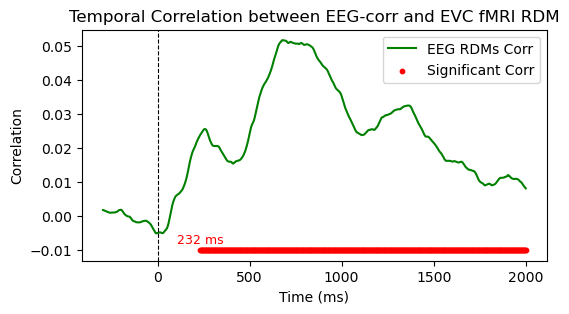

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Rescale and shift the x-axis
x = np.arange(1, 576, 1)
x_rescaled = [i * 4 for i in x]
x_shifted = np.array([i - 300 for i in x_rescaled])

# Find the index corresponding to 0ms and set the baseline period
zero_index = np.where(x_shifted >= 0)[0][0]
baseline_index = zero_index  # Use all timepoints before 0ms as baseline

# Compute baseline mean and standard deviation across subjects (baseline period)
mean_baseline_corr = np.mean(evc_eeg_correlations[:, :baseline_index], axis=0)
baseline_mean_corr = np.mean(mean_baseline_corr)
baseline_std_corr = np.std(mean_baseline_corr)

# Calculate the mean correlation across subjects for each timepoint
mean_corr_corr = np.mean(evc_eeg_correlations, axis=0)

# Apply baseline correction
baseline_correction = np.mean(mean_corr_corr[:baseline_index])
corrected_corr_corr = mean_corr_corr - baseline_correction

# Apply smoothing (assuming 'smooth' is a defined function)
smoothed_corr_corr = smooth(corrected_corr_corr)

# Find significant clusters (assuming 'find_significant_clusters' is defined)
significant_corr_indices = find_significant_clusters(
    smoothed_corr_corr, 
    baseline_mean_corr, 
    baseline_std_corr
)

# Determine the first significant time point and mark all points after it as significant
if len(significant_corr_indices) > 0:
    first_significant_index = significant_corr_indices[0]
    significant_corr_indices = np.arange(first_significant_index, len(smoothed_corr_corr))

# Plotting
plt.style.use('default')
plt.figure(figsize=(6, 3))

# Plot the smoothed mean correlation
plt.plot(x_shifted, smoothed_corr_corr, label='EEG RDMs Corr', color='green')

# Add labels, title, and a vertical line at 0ms
plt.xlabel('Time (ms)')
plt.ylabel('Correlation')
plt.title('Temporal Correlation between EEG- and EVC fMRI RDM')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')

# Plot significant clusters and annotate the first significant time point
if len(significant_corr_indices) > 0:
    plt.scatter(x_shifted[significant_corr_indices], 
                [-0.01] * len(significant_corr_indices), 
                color='red', s=10, label='Significant Corr')
    
    # Annotate the first significant time point near the marker
    first_sig_time = x_shifted[first_significant_index]
    plt.text(first_sig_time, -0.01 + 0.005, f'{first_sig_time} ms',
             color='red', fontsize=9, ha='center', va='top')

plt.legend()
plt.show()


### EEG RDMs based on correlations

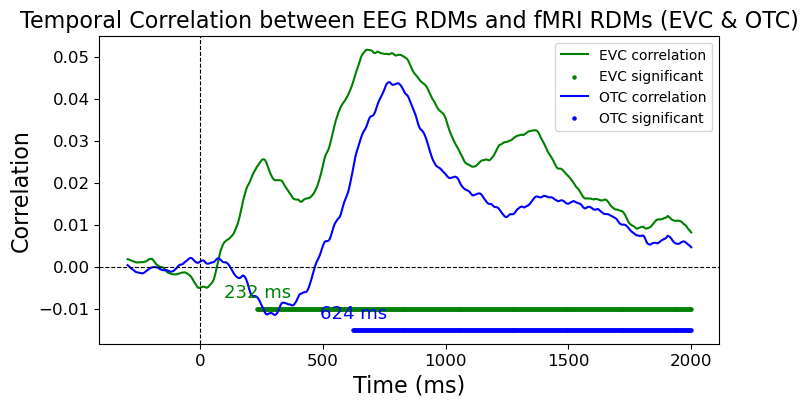

In [72]:
import numpy as np
import matplotlib.pyplot as plt

#---------------------------------------------------
# 1) Rescale and shift the x-axis
#---------------------------------------------------
x = np.arange(1, 576, 1)
x_rescaled = [i * 4 for i in x]
x_shifted = np.array([i - 300 for i in x_rescaled])

# Identify index corresponding to 0ms
zero_index = np.where(x_shifted >= 0)[0][0]
baseline_index = zero_index  # everything before 0ms considered baseline

#---------------------------------------------------
# 2) Baseline stats from your EVC data
#---------------------------------------------------
mean_baseline_corr = np.mean(evc_eeg_correlations[:, :baseline_index], axis=0)
baseline_mean_corr = np.mean(mean_baseline_corr)
baseline_std_corr = np.std(mean_baseline_corr)

#---------------------------------------------------
# 3) EVC: Compute mean, baseline-correct, smooth
#---------------------------------------------------
mean_corr_evc = np.mean(evc_eeg_correlations, axis=0)
baseline_correction_evc = np.mean(mean_corr_evc[:baseline_index])
corrected_corr_evc = mean_corr_evc - baseline_correction_evc
smoothed_corr_evc = smooth(corrected_corr_evc)

significant_evc_indices = find_significant_clusters(
    smoothed_corr_evc,
    baseline_mean_corr,
    baseline_std_corr
)
if len(significant_evc_indices) > 0:
    first_evc_index = significant_evc_indices[0]
    significant_evc_indices = np.arange(first_evc_index, len(smoothed_corr_evc))

#---------------------------------------------------
# 4) LOC: Compute mean, baseline-correct, smooth
#---------------------------------------------------
mean_corr_loc = np.mean(loc_eeg_correlations, axis=0)
baseline_correction_loc = np.mean(mean_corr_loc[:baseline_index])
corrected_corr_loc = mean_corr_loc - baseline_correction_loc
smoothed_corr_loc = smooth(corrected_corr_loc)

significant_loc_indices = find_significant_clusters(
    smoothed_corr_loc,
    baseline_mean_corr,
    baseline_std_corr
)
if len(significant_loc_indices) > 0:
    first_loc_index = significant_loc_indices[0]
    significant_loc_indices = np.arange(first_loc_index, len(smoothed_corr_loc))

#---------------------------------------------------
# 5) Plot the results
#---------------------------------------------------
plt.style.use('default')
plt.figure(figsize=(8, 4))

# Plot EVC correlation
plt.plot(x_shifted, smoothed_corr_evc,
         label='EVC correlation',
         color='green')

# Mark EVC significant points
if len(significant_evc_indices) > 0:
    plt.scatter(
        x_shifted[significant_evc_indices],
        [-0.01] * len(significant_evc_indices),
        color='green', s=5, label='EVC significant'
    )
    first_evc_time = x_shifted[first_evc_index]
    plt.text(first_evc_time, -0.01 + 0.006,
             f'{first_evc_time} ms',
             color='green', fontsize=13,
             ha='center', va='top')

# Plot LOC correlation
plt.plot(x_shifted, smoothed_corr_loc,
         label='OTC correlation',
         color='blue')

# Mark LOC significant points
if len(significant_loc_indices) > 0:
    plt.scatter(
        x_shifted[significant_loc_indices],
        [-0.015] * len(significant_loc_indices),
        color='blue', s=5, label='OTC significant'
    )
    first_loc_time = x_shifted[first_loc_index]
    plt.text(first_loc_time, -0.015 + 0.006,
             f'{first_loc_time} ms',
             color='blue', fontsize=13,
             ha='center', va='top')

#---------------------------------------------------
# 6) Finalize and Show Plot
#---------------------------------------------------
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.axhline(y=0.0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Time (ms)' ,fontsize=16)
plt.ylabel('Correlation', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Temporal Correlation between EEG RDMs and fMRI RDMs (EVC & OTC)', fontsize=16)
# plt.legend(
#     loc='upper left',
#     bbox_to_anchor=(1.04, 1), 
#     borderaxespad=0,
#     fontsize=14
# )
plt.legend(
    loc='upper right',  # Or 'upper left', 'best', etc.
    borderaxespad=0.5   # Adjust spacing around the legend box as needed
)

plt.show()


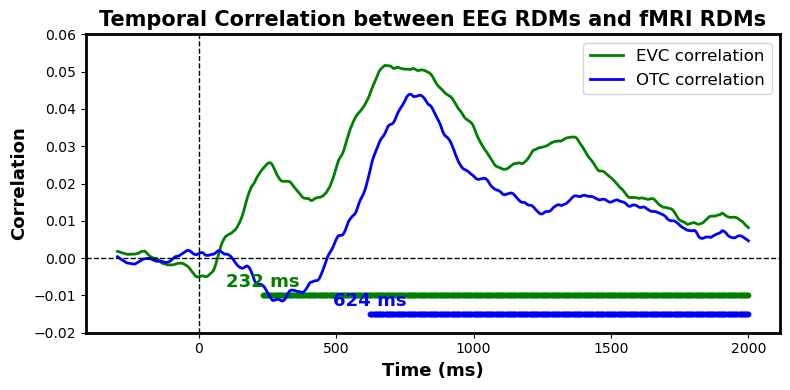

In [86]:
import numpy as np
import matplotlib.pyplot as plt

#---------------------------------------------------
# (Same data processing code as before)
#---------------------------------------------------
# x_shifted, smoothed_corr_evc, smoothed_corr_loc, etc.
# ... your existing code ...

plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 4))

# Optionally, set y-limit if you want a similar range to the example figure:
ax.set_ylim([-0.02, 0.06])  # Adjust as needed

# Make the axes spines thicker (a heavier outer box)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)

# Plot EVC correlation (thicker line, e.g. lw=2)
ax.plot(x_shifted, smoothed_corr_evc,
        label='EVC correlation',
        color='green', linewidth=2)

# Mark EVC significant points
if len(significant_evc_indices) > 0:
    ax.scatter(
        x_shifted[significant_evc_indices],
        [-0.01] * len(significant_evc_indices),
        color='green', s=10
    )
    first_evc_time = x_shifted[first_evc_index]
    ax.text(first_evc_time, -0.01 + 0.006,
            f'{first_evc_time} ms',
            color='green', fontsize=13,
            fontweight='bold',
            ha='center', va='top')

# Plot LOC correlation (thicker line)
ax.plot(x_shifted, smoothed_corr_loc,
        label='OTC correlation',
        color='blue', linewidth=2)

# Mark LOC significant points
if len(significant_loc_indices) > 0:
    ax.scatter(
        x_shifted[significant_loc_indices],
        [-0.015] * len(significant_loc_indices),
        color='blue', s=10
    )
    first_loc_time = x_shifted[first_loc_index]
    ax.text(first_loc_time, -0.015 + 0.006,
            f'{first_loc_time} ms',
            color='blue', fontsize=13,
            fontweight='bold',
            ha='center', va='top')

# Dashed lines at x=0 and y=0
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.axhline(0.0, color='black', linewidth=1, linestyle='--')

# Bold, larger axis labels
ax.set_xlabel('Time (ms)', fontsize=13, fontweight='bold')
ax.set_ylabel('Correlation', fontsize=13, fontweight='bold')

# Bold, larger tick labels
ax.tick_params(axis='both', labelsize=10)  
# for tick in ax.get_xticklabels() + ax.get_yticklabels():
#     tick.set_fontweight('bold')

# Bold, larger title
ax.set_title('Temporal Correlation between EEG RDMs and fMRI RDMs', 
             fontsize=15, fontweight='bold')

# Legend inside plot with bigger font
ax.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()


In [73]:
import numpy as np
import matplotlib.pyplot as plt
import os

# [1] ... your code up to computing x_shifted, smoothed_corr_evc, smoothed_corr_loc ...
output_folder = r'F:/yujun/projects/IAPS_Searchlight/outputs'
# Combine time (x_shifted), EVC, and OTC into one 2D array
# Each row will be: [time_value, EVC_corr, OTC_corr]
data_to_save = np.column_stack([evc_eeg_correlations, loc_eeg_correlations])

# [3] (Optional) If you also want to save it as NumPy .npy file:
npy_file = os.path.join(output_folder, 'EEG_fMRI_correlations.npy')
np.save(npy_file, data_to_save)


In [2]:
import numpy as np
from scipy import stats

def generate_sample(mean, variance, sample_size):

    std_dev = np.sqrt(variance)
    return np.random.normal(loc=mean, scale=std_dev, size=sample_size)

def is_significantly_different(sample1, sample2, alpha=0.05):

    t_stat, p_value = stats.ttest_ind(sample1, sample2, equal_var=True)
    return p_value < alpha, p_value

# Example usage:
# Parameters for Sample 1
mean1 = 0.49
variance1 = 3.0  # Variance (std = 2.0)
sample_size1 = 5

# Parameters for Sample 2
mean2 = 0.53
variance2 = 3.0  # Variance (std = 2.0)
sample_size2 = 5

# Generate the samples
sample1 = generate_sample(mean1, variance1, sample_size1)
sample2 = generate_sample(mean2, variance2, sample_size2)

# Test for statistical significance
significant, p_val = is_significantly_different(sample1, sample2)

if significant:
    print(f"The samples are significantly different (p = {p_val:.4f}).")
else:
    print(f"No significant difference found (p = {p_val:.4f}).")


No significant difference found (p = 0.6641).


In [14]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# Assume test set size n (the same for both models for simplicity)
n = 1000

# Calculate the number of correct predictions for each model:
correct_A = int(0.49 * n)
correct_B = int(0.53 * n)

# Create an array for counts and an array for total observations for both models
counts = np.array([correct_A, correct_B])
nobs = np.array([n, n])

# Perform the two-proportion z-test
stat, p_value = proportions_ztest(counts, nobs)

print(f"Z-test statistic: {stat:.4f}, p-value: {p_value:.4f}")
if p_value < 0.05:
    print("The difference in accuracy is statistically significant.")
else:
    print("The difference in accuracy is not statistically significant.")


Z-test statistic: -5.6580, p-value: 0.0000
The difference in accuracy is statistically significant.
